# <img src="https://intelectacup.com/favicon.ico" /> Intelecta Cup - Data Mining Competition 2025  

---

## Informasi Tim
**Nama Tim:** Cognivio

**Institusi:** Politeknik Negeri Malang

| No | Anggota         | Peran                      | 
|----|----------------------|----------------------------|
| 1  | Vidi Joshubzky Saviola    | Model Developer   |
| 2  | Cakra Wangsa May Ahmad Widodo             | ML Researcher              |
| 3  | Farrel Augusta Dinata             | ML Researcher Lead              |
| 4  | Hidayat Widi Saputra             | Model Developer   |

---

<div style="text-align:center; font-style:italic; opacity:0.8;">
  © 2025 Cognivio Team. All rights reserved.
</div>

# 0. Preparation

In [15]:
import os
import sys
import random
from itertools import combinations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, RandomForestClassifier
from sklearn.metrics import make_scorer, mean_absolute_percentage_error
from sklearn.linear_model import Ridge
import xgboost
from xgboost import XGBRegressor
import lightgbm
from lightgbm import LGBMRegressor
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

# Detect environment
def detect_environment() -> str:
    """Detect if running in Colab, Kaggle, or local environment"""
    if 'google.colab' in sys.modules:
        return 'colab'
    elif 'kaggle_secrets' in sys.modules or os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
        return 'kaggle'
    else:
        return 'local'

ENV = detect_environment()
print(f'🔍 Detected environment: {ENV.upper()}')


print(f'Python version: {sys.version}')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')
print(f'Scikit-learn version: {sklearn.__version__}')
print(f'XGBoost version: {xgboost.__version__}')
print(f'LightGBM version: {lightgbm.__version__}')

🔍 Detected environment: LOCAL
Python version: 3.13.0 | packaged by conda-forge | (main, Nov 27 2024, 19:03:49) [MSC v.1942 64 bit (AMD64)]
NumPy version: 2.3.1
Pandas version: 2.2.3
Scikit-learn version: 1.7.2
XGBoost version: 2.1.3
LightGBM version: 4.6.0


# 1. Data Collection

In [3]:
def setup_dataset_paths(env: str) -> dict[str, str]:
    """Setup dataset paths based on environment"""
    
    # Kaggle environment
    if env == 'kaggle':
        return {
            'train_csv': "/kaggle/input/intelecta-cup-data-mining-competition/train.csv",
            'test_csv': "/kaggle/input/intelecta-cup-data-mining-competition/test.csv",
            'save_dir': "/kaggle/working"
        }
    
    # Local environment
    if env == 'local':
        base_path = "../data" # TODO: Adjust your local environment path
        return {
            'train_csv': f"{base_path}/train.csv",
            'test_csv': f"{base_path}/test.csv",
            'save_dir': f"{base_path}/models"
        }
    
    # Colab environment
    dataset_name = "intelecta-cup-data-mining-competition"
    local_path = "/content/dataset"
    
    # Check if dataset already exists
    if os.path.exists(local_path):
        return {
            'train_csv': f"{local_path}/train.csv",
            'test_csv': f"{local_path}/test.csv",
            'save_dir': "/content/drive/MyDrive/PROJECTS/Cognivio/models"
        }
    
    print("📥 Setting up tabular dataset in Colab...")
    
    # Setup Kaggle credentials
    _setup_kaggle_credentials()
    
    # Download and extract dataset
    _download_and_extract_dataset(dataset_name, local_path)
    
    return {
        'train_csv': f"{local_path}/train.csv",
        'test_csv': f"{local_path}/test.csv",
        'save_dir': "/content/drive/MyDrive/PROJECTS/Cognivio/models"
    }

def _setup_kaggle_credentials() -> None:
    """Setup Kaggle credentials in Colab"""
    kaggle_json_drive = "/content/drive/MyDrive/kaggle.json"
    kaggle_json_local = "/root/.kaggle/kaggle.json"
    
    # Try to copy from Google Drive first
    if os.path.exists(kaggle_json_drive):
        print("📂 Copying kaggle.json from Drive...")
        !mkdir -p /root/.kaggle
        !cp "{kaggle_json_drive}" "{kaggle_json_local}"
        !chmod 600 "{kaggle_json_local}"
        print("✅ Kaggle credentials loaded from Drive")
        return
    
    # Fallback: manual upload
    print("⚠️ Please upload kaggle.json manually or place it in Drive root folder")
    from google.colab import files  # type: ignore
    uploaded = files.upload()
    
    for fn in uploaded.keys():
        !mkdir -p /root/.kaggle
        !mv "{fn}" "/root/.kaggle/kaggle.json"
        !chmod 600 "/root/.kaggle/kaggle.json"
        print(f"✅ Kaggle credentials uploaded: {fn}")


def _download_and_extract_dataset(
    dataset_name: str, 
    local_path: str
) -> None:
    """Download and extract Kaggle competition dataset"""
    import zipfile
    
    # Download dataset
    !kaggle competitions download -c {dataset_name} -p /content
    
    # Extract dataset
    zip_path = f"/content/{dataset_name}.zip"
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Dataset zip not found: {zip_path}")
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(local_path)
    
    print(f"✅ Dataset extracted to {local_path}")

# Setup paths
paths = setup_dataset_paths(ENV)
print(f"📁 Dataset paths configured for {ENV}:")
for key, path in paths.items():
    exists = "✅" if os.path.exists(path) else "⚠️"
    print(f"   {key}: {path} {exists}")

# Create save directory
os.makedirs(paths['save_dir'], exist_ok=True)

# Set random seed for reproducibility
def set_seed(seed: int = 20) -> None:
    random.seed(seed)
    np.random.seed(seed)

RANDOM_SEED = 20
set_seed(seed=RANDOM_SEED)

📁 Dataset paths configured for local:
   train_csv: ../data/train.csv ✅
   test_csv: ../data/test.csv ✅
   save_dir: ../data/models ✅


# 2. Data Cleaning & Preprocessing

## 2.1 Load Data

In [4]:
df = pd.read_csv(paths['train_csv'])

display(df.head(20))
display(df.describe())
display(df.info())

,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
0,0,2015,USA,South,Soybeans,1658.71,13.36,2.620,10,74.41,38.97,2.64,46.07,Manajemen Air,20.43
1,1,2022,China,East,Wheat,1478.74,9.55,0.570,2,36.90,49.99,77.22,88.87,Rotasi Tanaman,-0.33
2,2,2000,India,'West Bengal',Fruits,1252.34,27.37,2.115,3,34.21,2.75,83.94,77.15,Pertanian Organik,12.97
3,3,2008,Nigeria,'North West',Sugarcane,209.89,16.16,4.158,5,91.74,36.80,37.50,73.59,Pertanian Organik,12.81
4,4,1991,Canada,Ontario,Vegetables,1086.67,3.71,2.430,0,14.72,7.22,28.72,41.90,Tanpa Adaptasi,4.22
5,5,1990,Australia,Queensland,Fruits,2265.29,2.33,2.030,4,79.39,48.80,3.30,77.63,Tanpa Adaptasi,14.70
6,6,2017,Russia,Northwestern,Rice,586.35,7.00,1.070,10,88.96,42.20,71.15,45.82,Tanaman Tahan Kekeringan,7.34
7,7,1995,China,Central,Vegetables,2281.25,24.21,2.907,1,27.44,23.94,13.96,50.97,Tanaman Tahan Kekeringan,16.97
8,8,2016,France,'Provence-Alpes-Cote d’Azur',NaN,792.07,10.31,3.420,1,51.51,4.60,75.99,94.94,Pertanian Organik,30.23
9,9,1991,Nigeria,'North West',Cotton,1746.26,25.28,2.772,7,39.09,9.33,90.96,59.65,Manajemen Air,20.30


,ID,Tahun,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Suhu_Rata_Rata_C
count,8000.00000,8000.000000,7821.000000,8000.000000,7800.000000,8000.000000,7819.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,3999.50000,2007.032750,1615.503060,15.271184,2.238219,4.989750,55.394575,24.920015,49.706654,64.824446,15.206680
std,2309.54541,10.106035,807.932322,8.551214,0.996626,3.171814,26.034847,14.454507,28.674985,20.153617,11.490611
min,0.00000,1990.000000,200.170000,0.500000,0.450000,0.000000,10.010000,0.000000,0.030000,30.000000,-4.990000
25%,1999.75000,1998.000000,929.290000,7.860000,1.449000,2.000000,32.905000,12.550000,25.160000,47.115000,5.377500
50%,3999.50000,2007.000000,1614.790000,15.250000,2.170000,5.000000,55.340000,24.930000,49.270000,64.675000,15.140000
75%,5999.25000,2016.000000,2316.820000,22.820000,2.930000,8.000000,77.770000,37.382500,74.430000,82.302500,25.340000
max,7999.00000,2024.000000,2999.670000,30.000000,5.000000,10.000000,99.990000,49.990000,99.990000,100.000000,35.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              8000 non-null   int64  
 1   Tahun                           8000 non-null   int64  
 2   Nama_Negara                     8000 non-null   object 
 3   Wilayah                         8000 non-null   object 
 4   Jenis_Tanaman                   7781 non-null   object 
 5   Total_Curah_Hujan_mm            7821 non-null   float64
 6   Emisi_CO2_JT_Ton                8000 non-null   float64
 7   Hasil_Panen_Ton_per_HA          7800 non-null   float64
 8   Kejadian_Cuaca_Ekstrim          8000 non-null   int64  
 9   Akses_Irigasi                   7819 non-null   float64
 10  Penggunaan_Pestisida_KG_per_HA  8000 non-null   float64
 11  Penggunaan_Pupuk_KG_per_HA      8000 non-null   float64
 12  Indeks_Kesehatan_Tanah          80

None

## 2.2 Split Dataset for Each Country

Mengurutkan data time series

In [5]:
if df['Tahun'].is_monotonic_increasing == False or df['Tahun'].is_monotonic_decreasing == False:
    print('Dataset tidak terurut berdasarkan waktu (tahun)')
else:
    print('Dataset sudah terurut berdasarkan waktu (tahun)')

Dataset tidak terurut berdasarkan waktu (tahun)


Mengurutkan data berdasarkan **Tahun**, **Wilayah**, dan **Jenis_Tanaman**

In [6]:
df = df.sort_values(
    by=['Tahun', 'Nama_Negara', 'Wilayah', 'Jenis_Tanaman'],
)
df.head(60)

,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
4819,4819,1990,Argentina,Northeast,Coffee,1238.02,5.97,0.970,8,80.49,26.03,56.52,81.69,Tanpa Adaptasi,1.01
4612,4612,1990,Argentina,Northeast,Corn,2412.68,21.37,1.719,9,13.86,33.40,97.57,54.26,Manajemen Air,11.81
4824,4824,1990,Argentina,Northeast,Cotton,1282.89,21.74,0.837,4,46.43,42.33,45.91,71.53,Rotasi Tanaman,27.75
1035,1035,1990,Argentina,Northeast,Fruits,2187.52,14.57,3.740,8,24.94,1.11,92.01,87.66,Rotasi Tanaman,30.46
2414,2414,1990,Argentina,Northeast,Fruits,893.09,6.89,3.700,8,57.33,43.73,23.63,59.92,Tanaman Tahan Kekeringan,10.46
170,170,1990,Argentina,Northeast,Rice,790.69,27.16,1.899,6,59.14,37.87,9.89,67.62,Pertanian Organik,26.70
5438,5438,1990,Argentina,Northeast,Sugarcane,2874.40,22.56,4.221,0,96.19,24.62,68.72,78.90,Tanaman Tahan Kekeringan,15.02
7483,7483,1990,Argentina,Northeast,Vegetables,444.01,13.18,2.484,6,66.28,21.31,33.35,98.73,Rotasi Tanaman,6.79
5251,5251,1990,Argentina,Northeast,NaN,720.38,11.03,2.360,0,93.23,37.02,51.92,61.07,Rotasi Tanaman,10.91
2036,2036,1990,Argentina,Northwest,Coffee,2387.84,10.37,2.820,4,36.12,21.40,53.24,62.53,Rotasi Tanaman,11.93


Data splitting

In [ ]:
# uncomment below if you want to export the sorted data to CSV file
# for country in df['Nama_Negara'].unique():
#     country_df = df[df['Nama_Negara'] == country]
    
#     country_df.to_csv(f'../outputs/{country}_sorted.csv', index=False)

## 2.3 Checking Correlation between Each Features

### 2.3.1 Numeric-numeric features

                                   Tahun  Total_Curah_Hujan_mm  \
Tahun                           1.000000              0.012556   
Total_Curah_Hujan_mm            0.012556              1.000000   
Emisi_CO2_JT_Ton               -0.005061             -0.007133   
Hasil_Panen_Ton_per_HA         -0.001188              0.023763   
Kejadian_Cuaca_Ekstrim          0.000736              0.004888   
Akses_Irigasi                  -0.007673             -0.013014   
Penggunaan_Pestisida_KG_per_HA -0.003620              0.004846   
Penggunaan_Pupuk_KG_per_HA      0.021150             -0.020502   
Indeks_Kesehatan_Tanah         -0.006140             -0.018602   
Suhu_Rata_Rata_C               -0.008861              0.008695   

                                Emisi_CO2_JT_Ton  Hasil_Panen_Ton_per_HA  \
Tahun                                  -0.005061               -0.001188   
Total_Curah_Hujan_mm                   -0.007133                0.023763   
Emisi_CO2_JT_Ton                        1.000

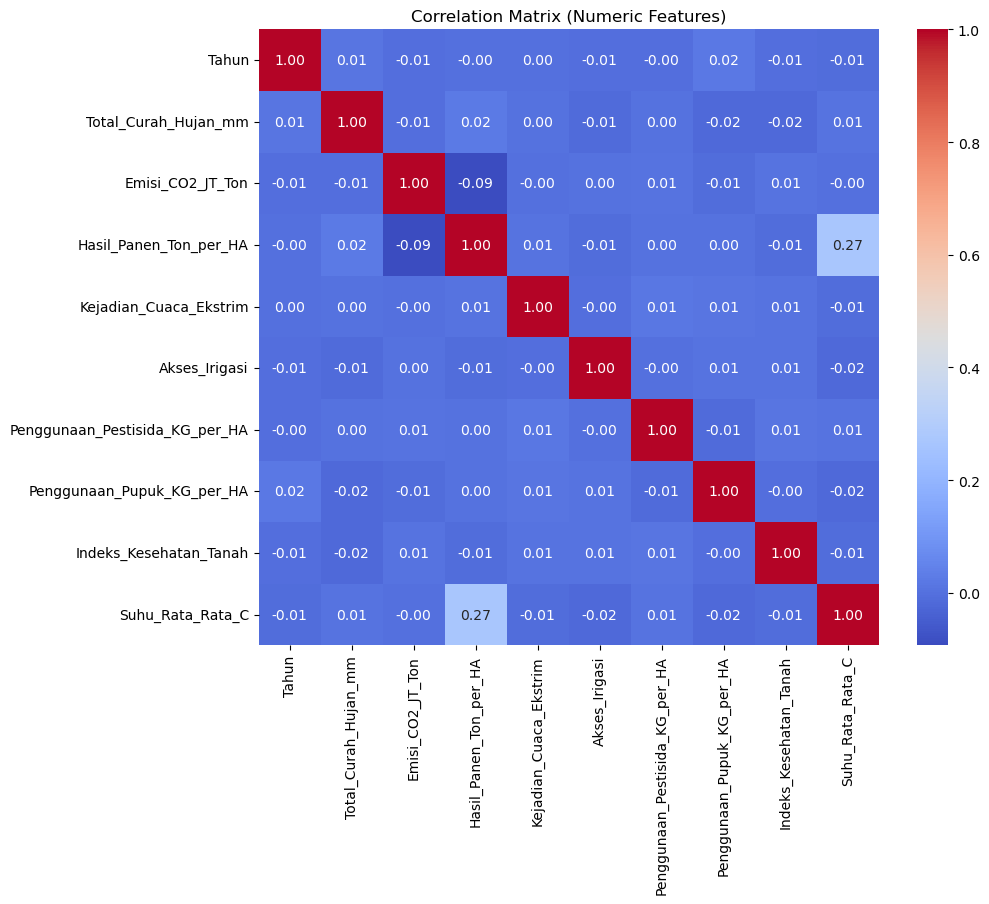

In [7]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['ID'])

# Compute correlation matrix
corr_matrix = numeric_df.corr(method='pearson')

# Display matrix
print(corr_matrix)

# Optional: visualize heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

### 2.3.2 Numeric-categorical features

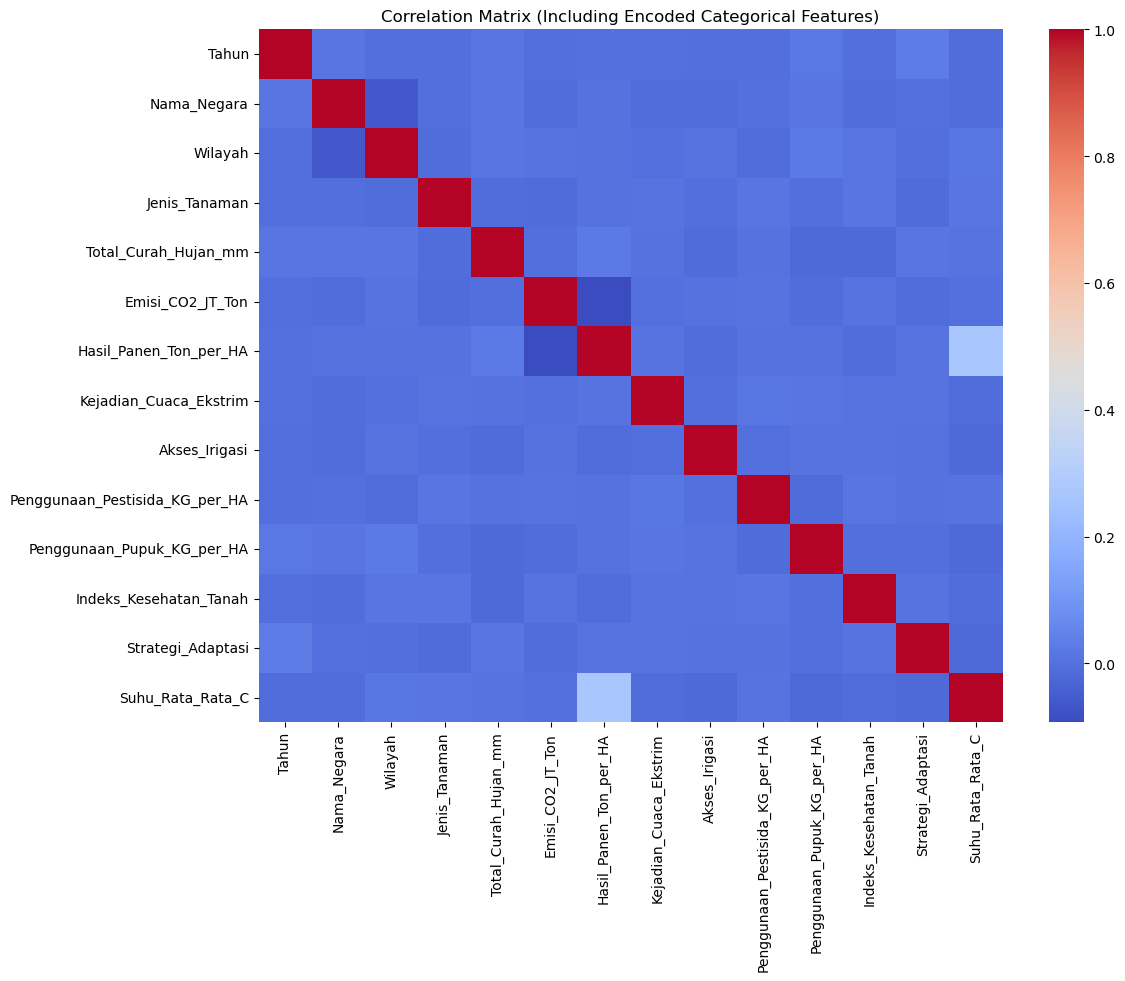

In [13]:
df_encoded = df.copy()
df_encoded = df_encoded.drop(columns=['ID'])

for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

corr_matrix = df_encoded.corr()
plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix (Including Encoded Categorical Features)")
plt.show()

### 2.3.3 Linearity Correlation

#### Numeric features

Total paris: 45


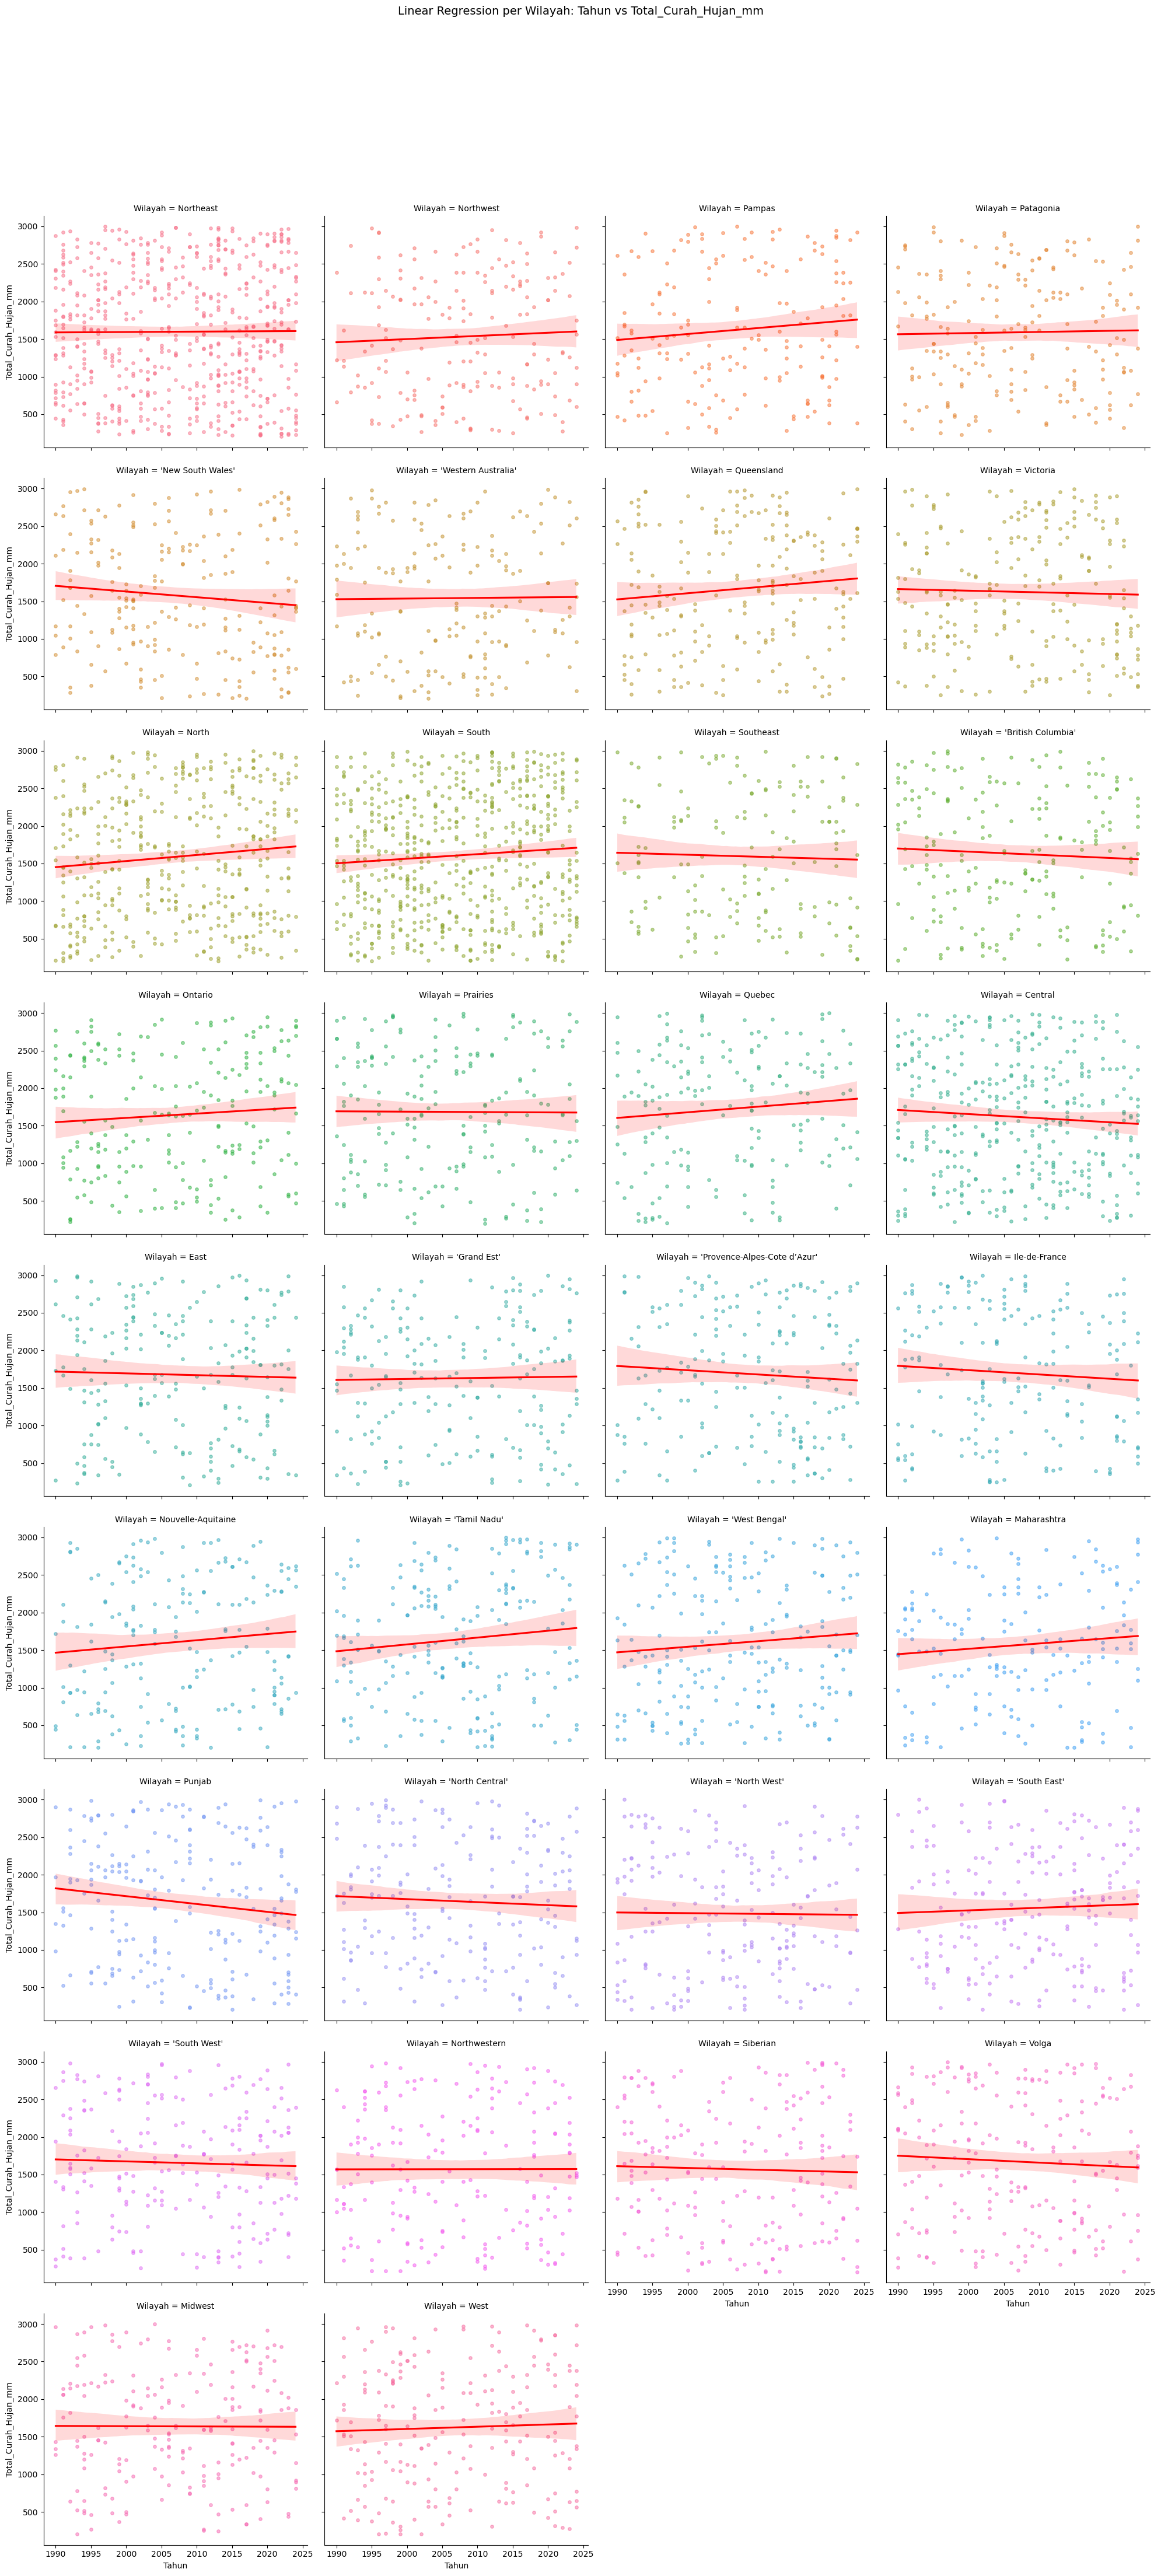

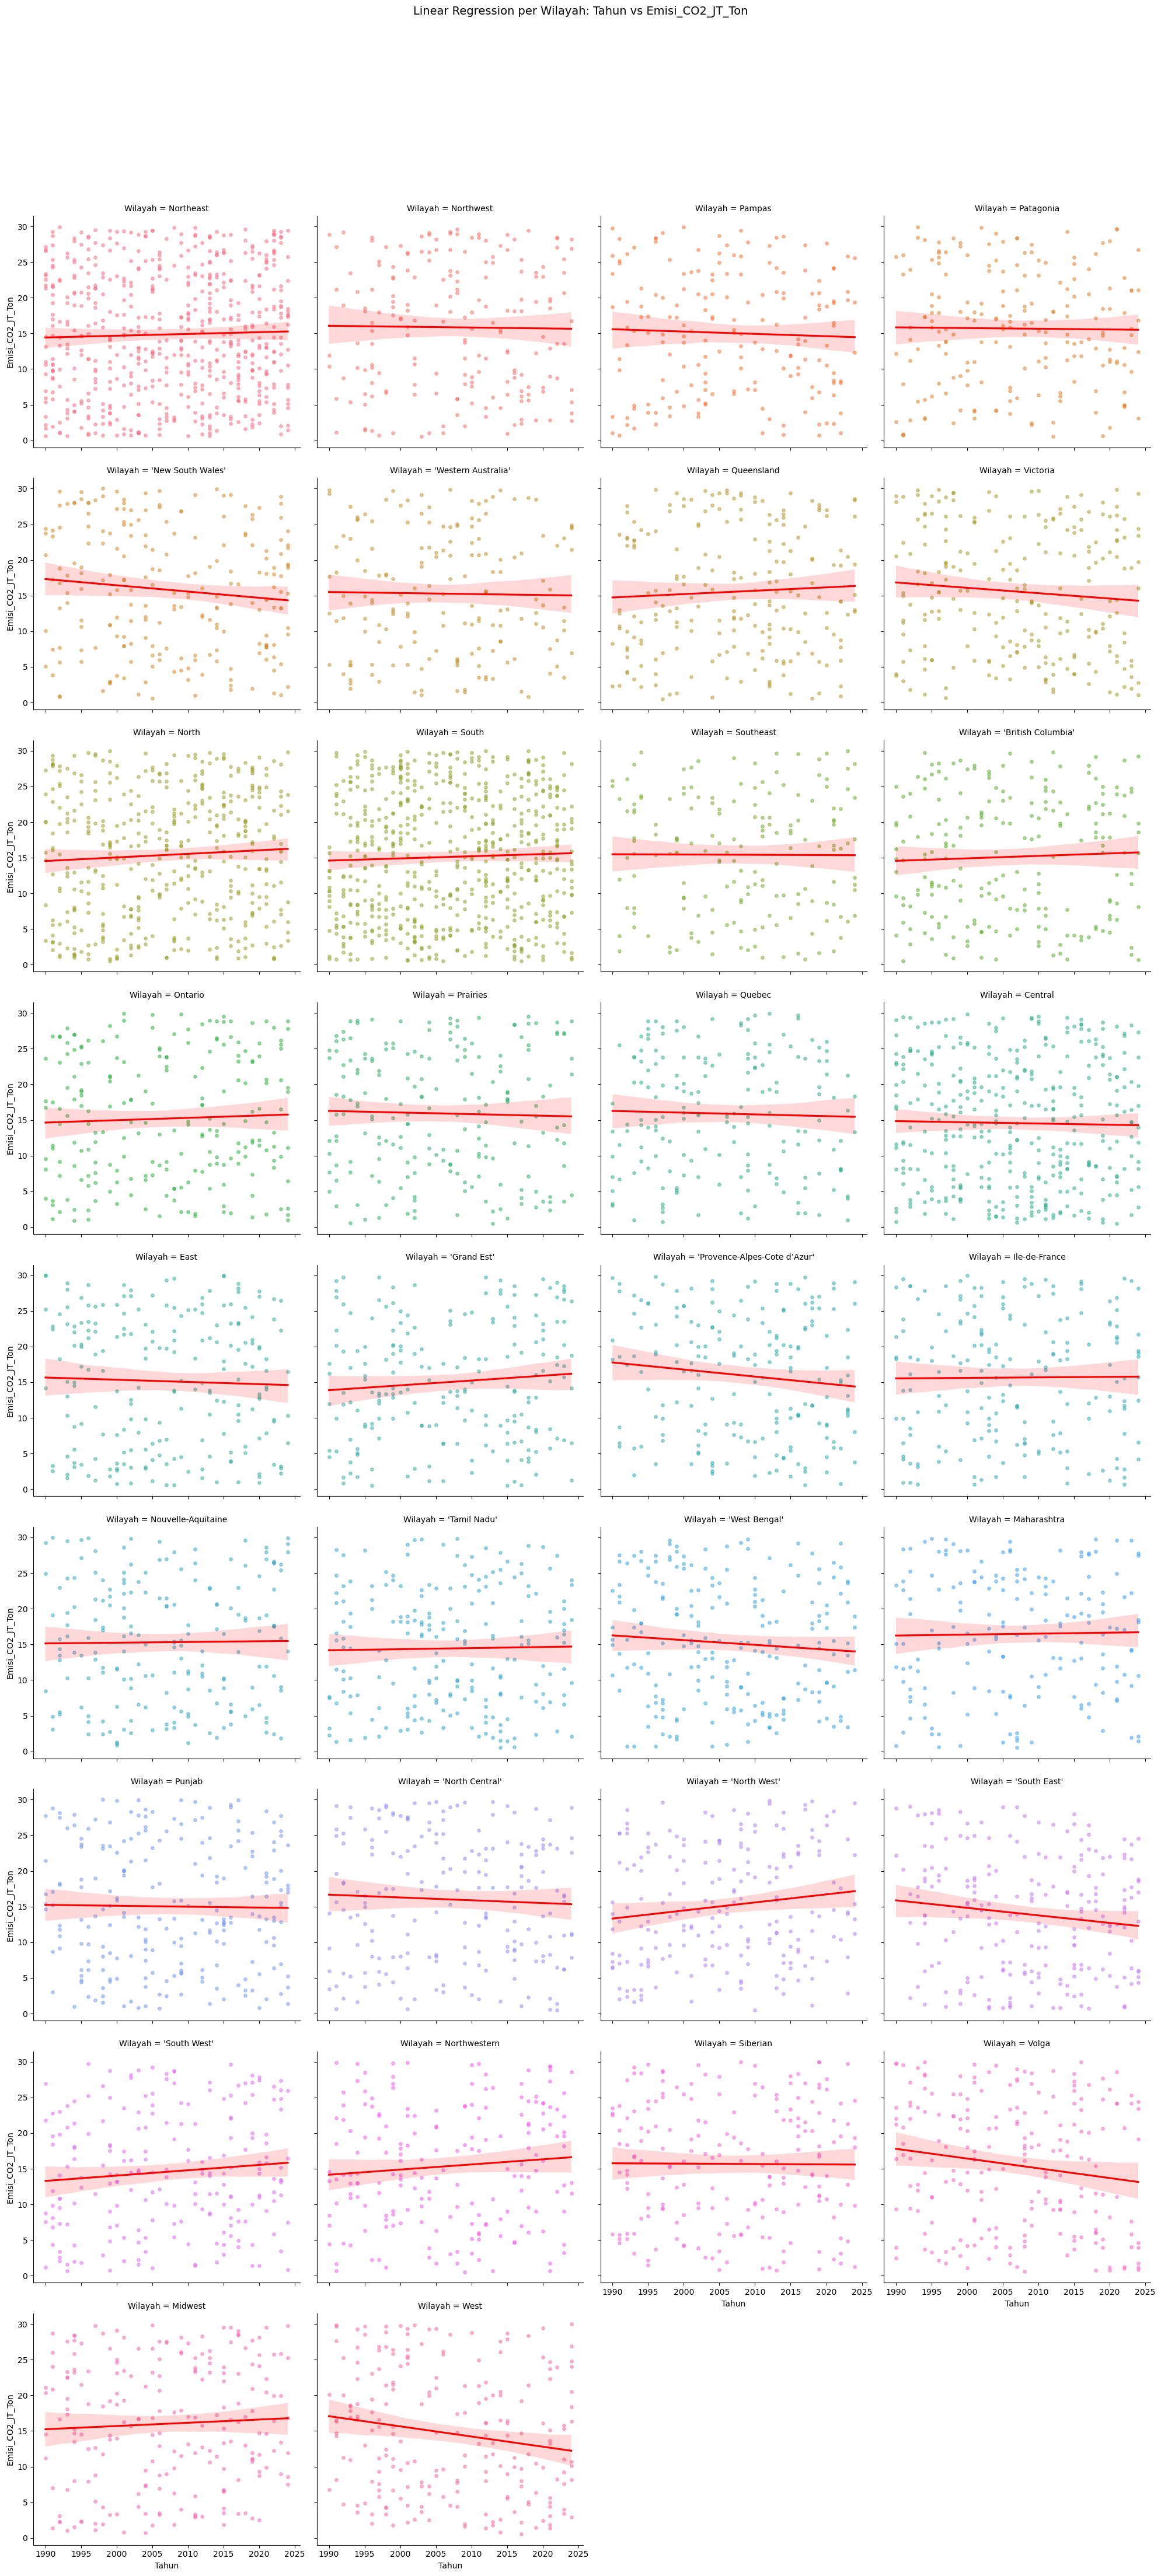

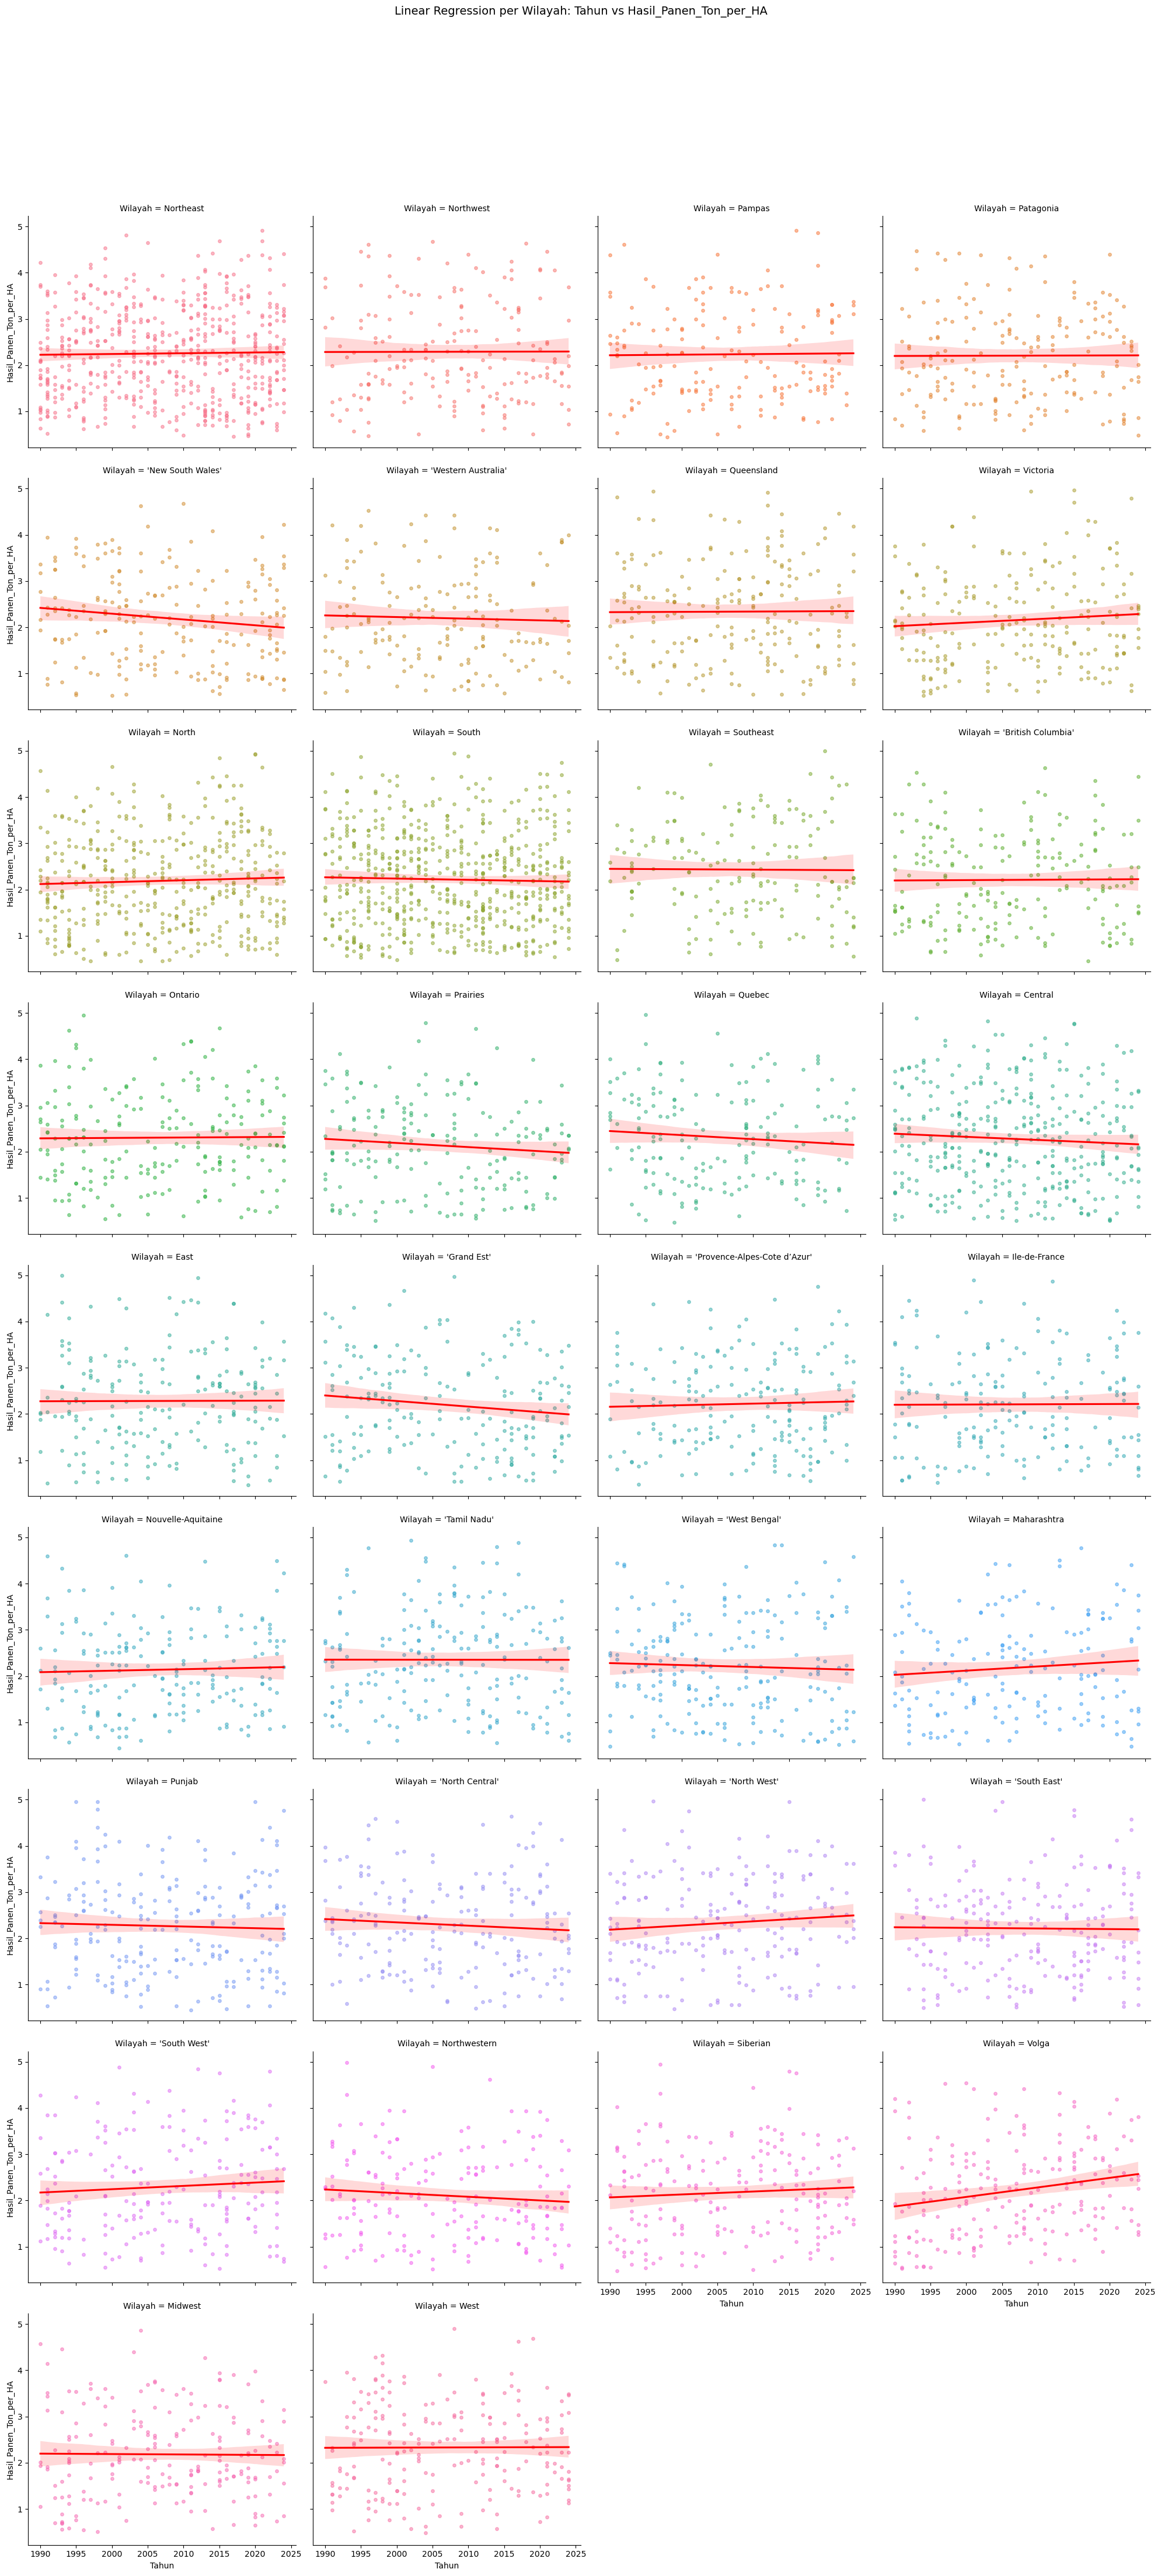

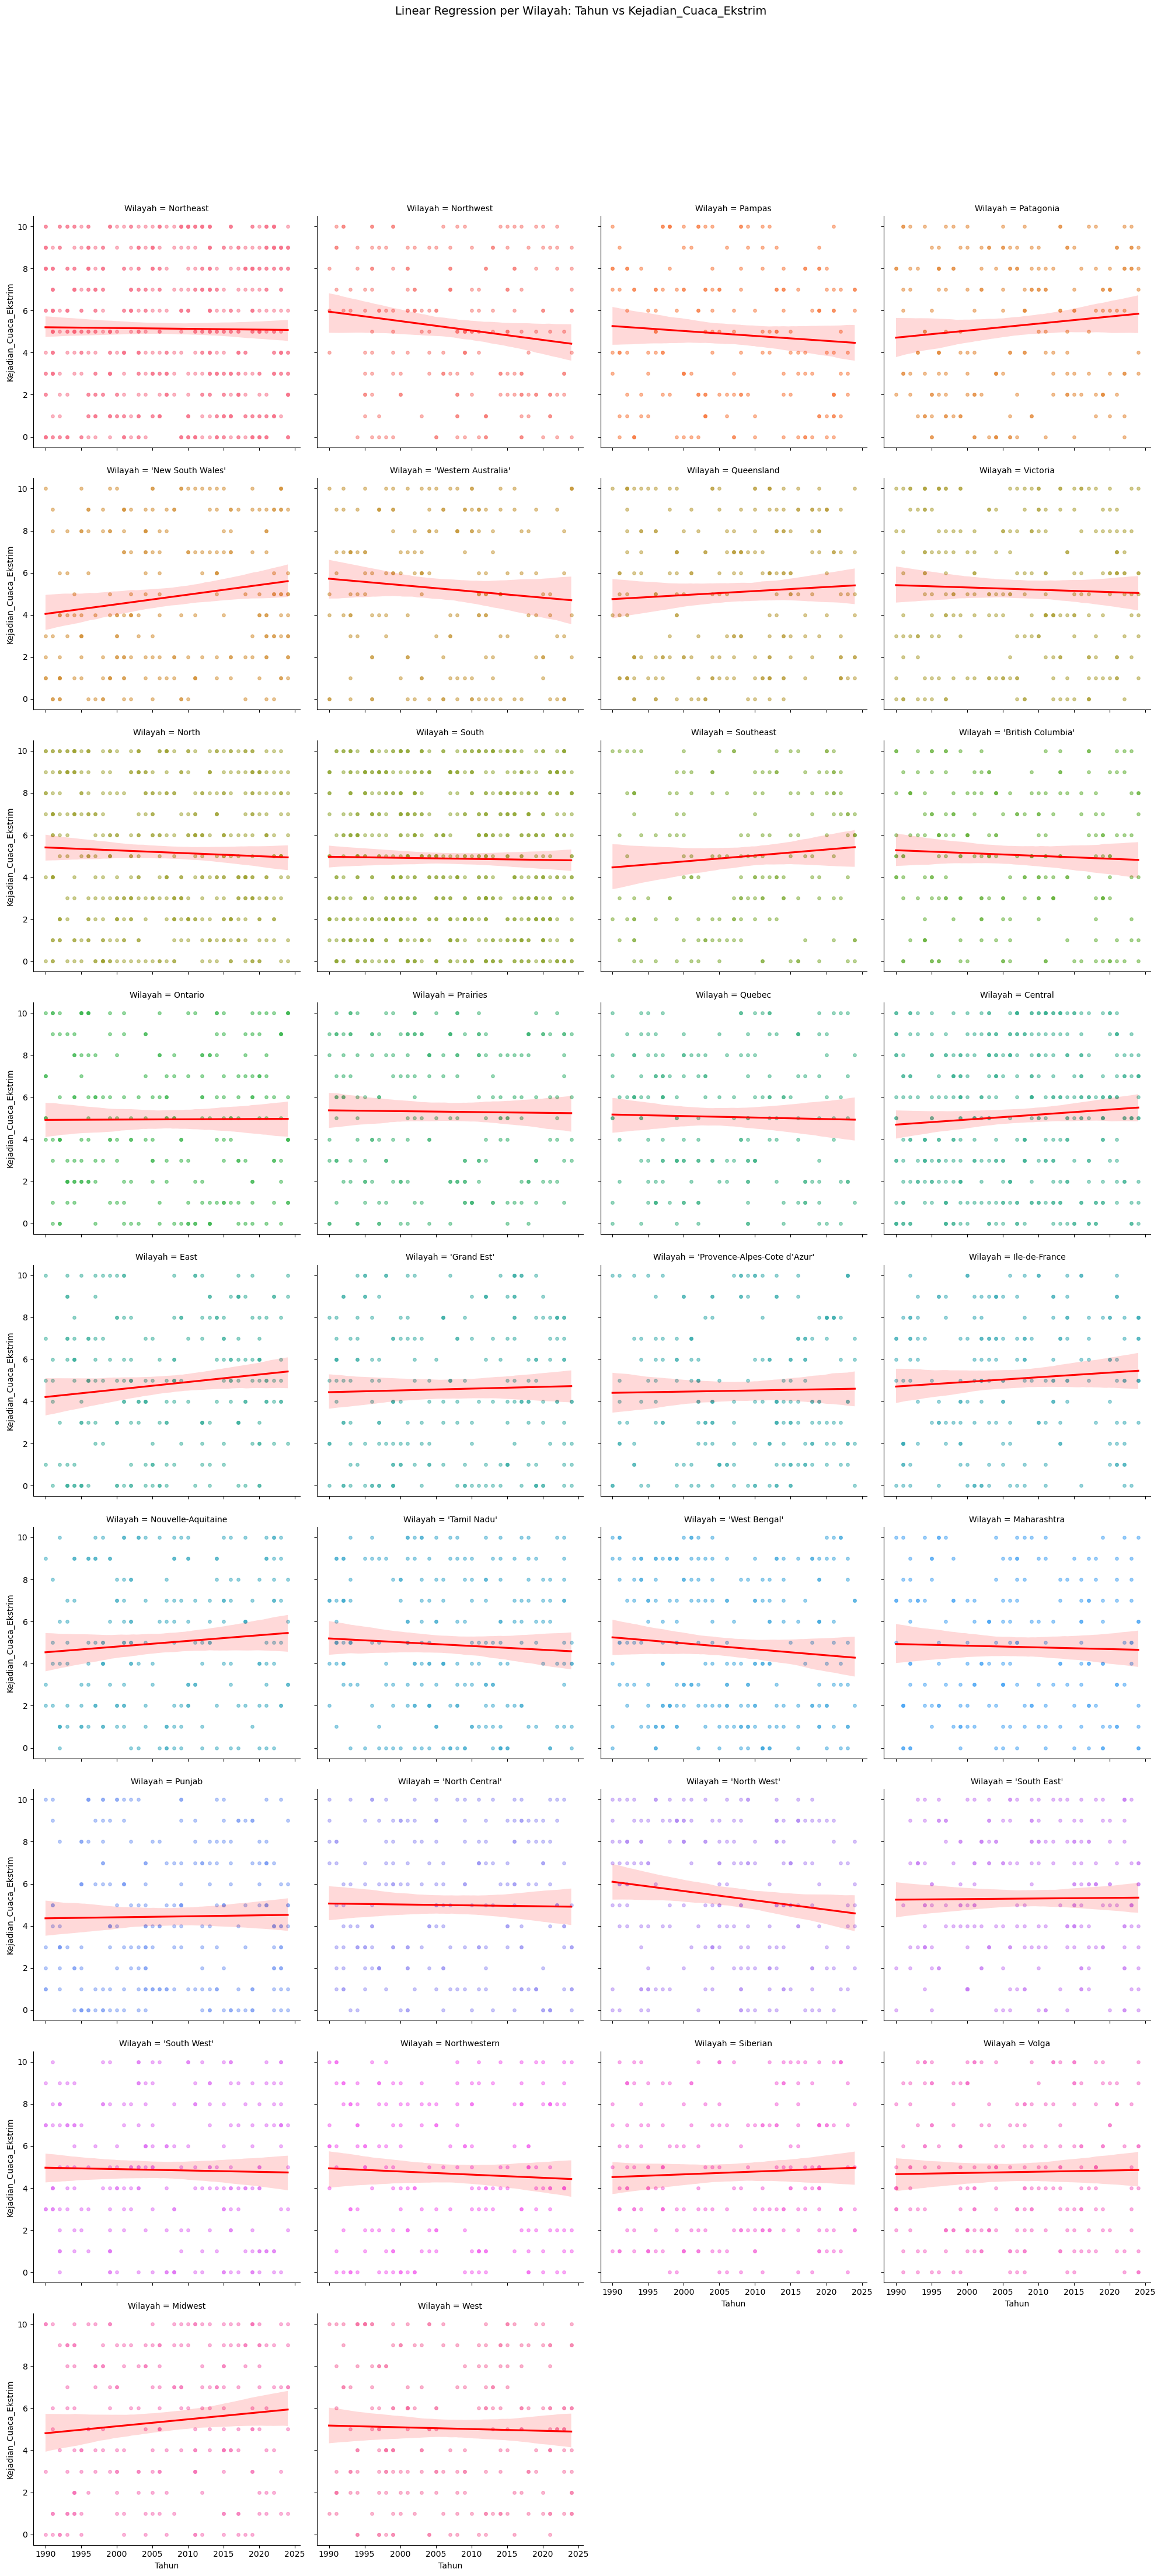

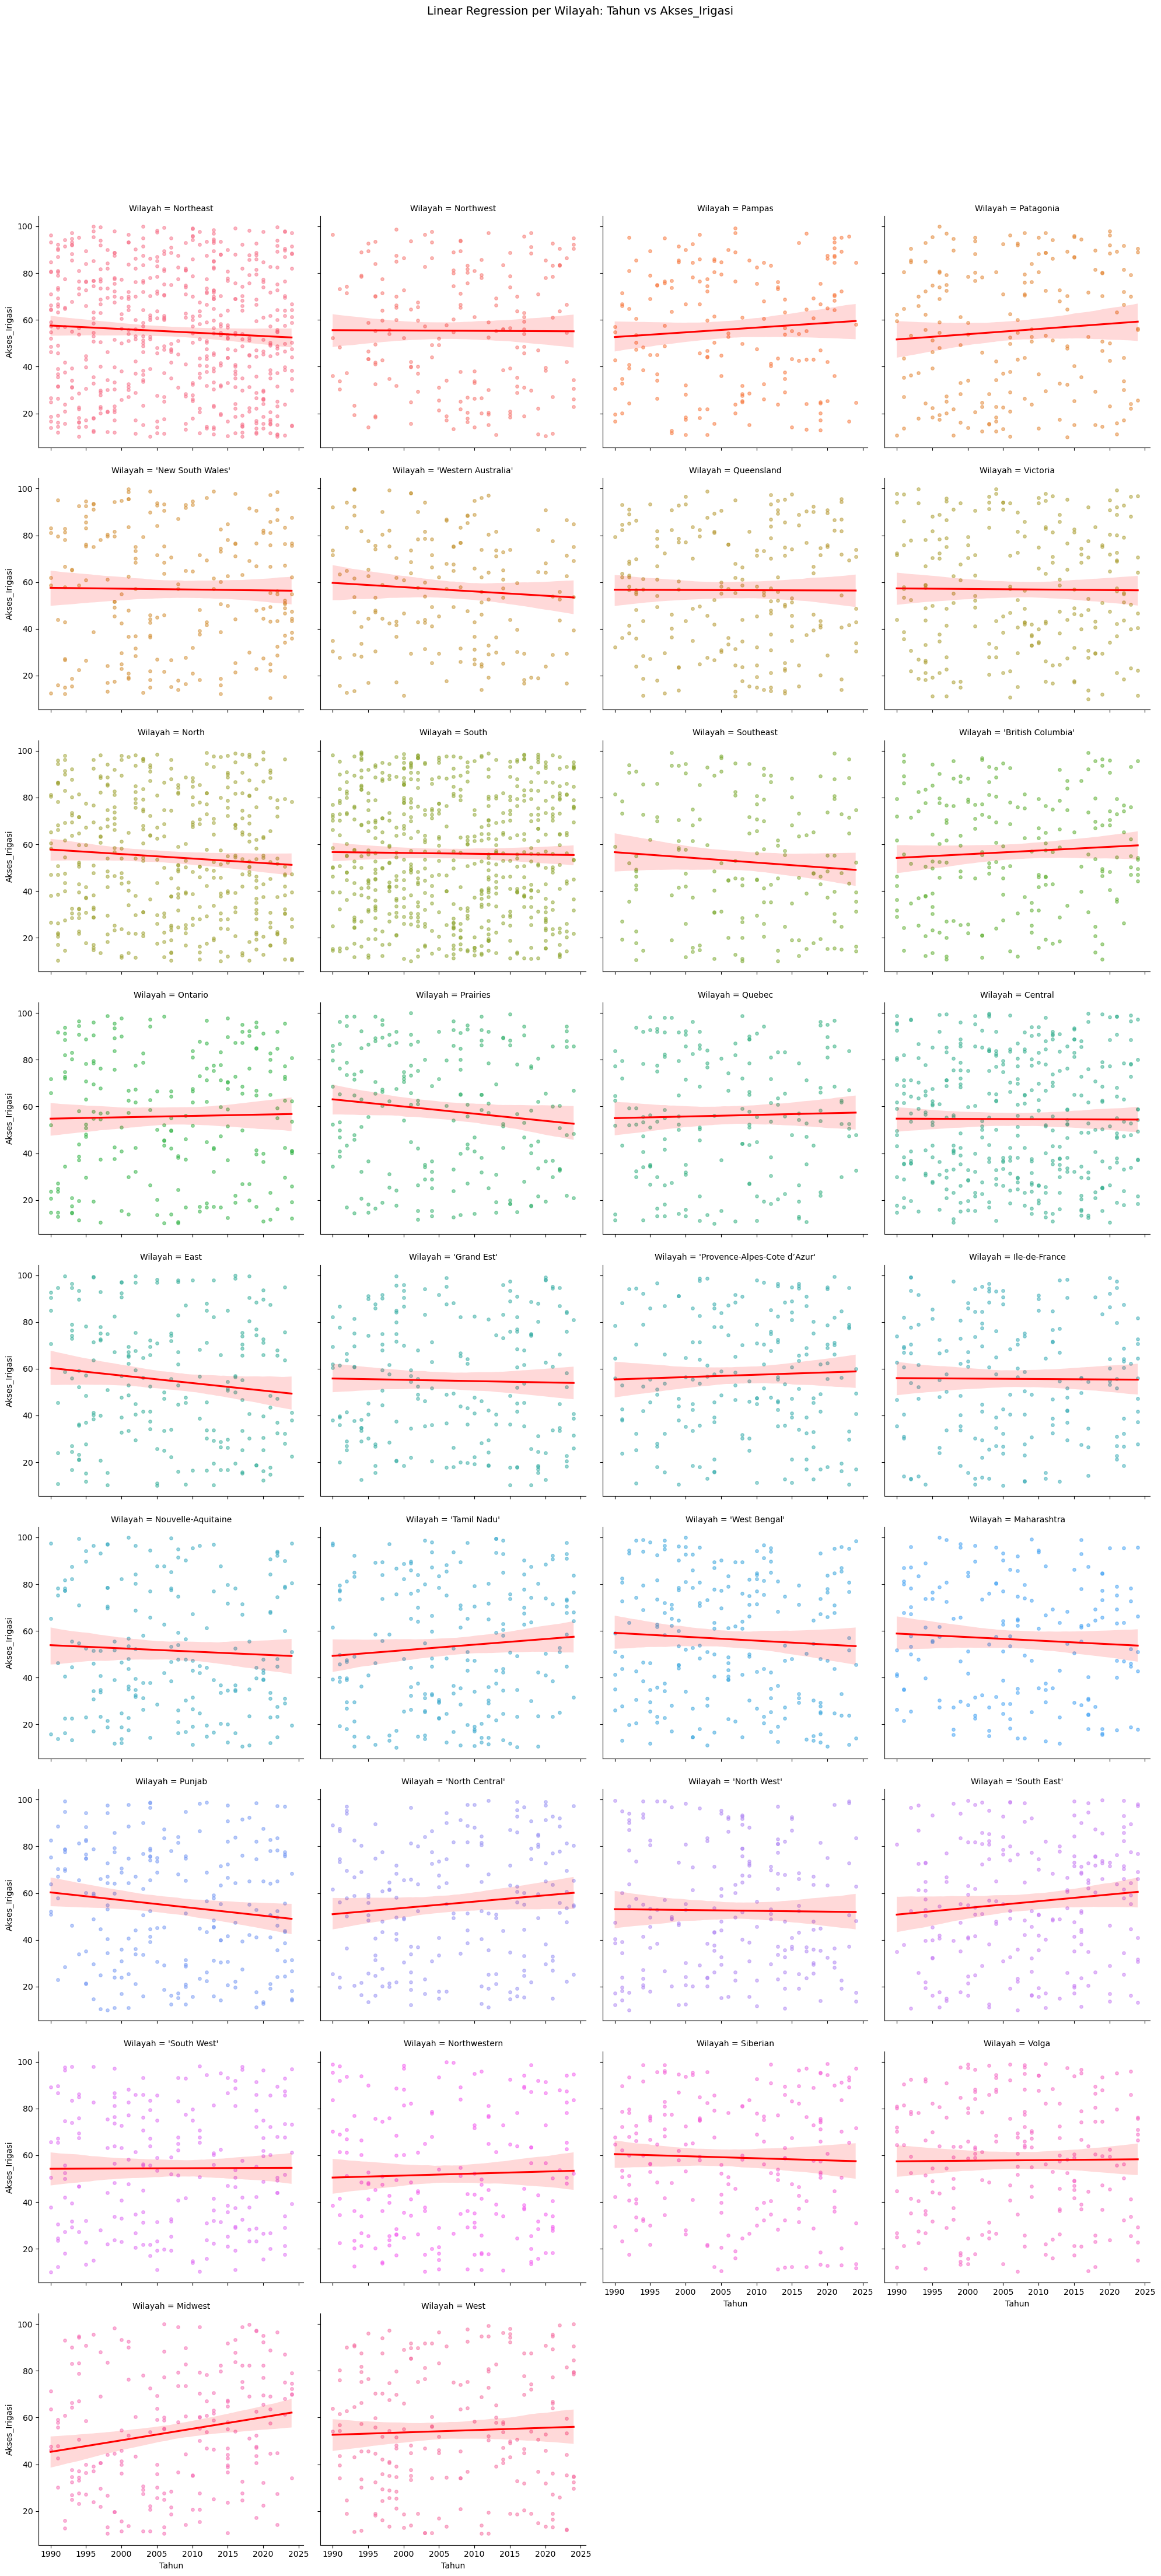

In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('ID')
numeric_df = df[numeric_cols]

pairs = list(combinations(numeric_cols, 2))
print(f'Total paris: {len(pairs)}')

def plot_feature_correlations(
    df: pd.DataFrame, 
    group_col: str = 'Wilayah', 
    max_plots: int = 10
) -> None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('ID')
    pairs = list(combinations(numeric_cols, 2))

    for i, (x, y) in enumerate(pairs[:max_plots]):  # limit to first N pairs
        sns.lmplot(
            data=df,
            x=x,
            y=y,
            hue=group_col,
            col=group_col,
            col_wrap=4,
            scatter_kws={'alpha': 0.5, 's': 15},
            line_kws={'color': 'red'}
        )
        plt.subplots_adjust(top=0.9)
        plt.suptitle(f'Linear Regression per {group_col}: {x} vs {y}', fontsize=14)
        plt.show()

plot_feature_correlations(df, group_col='Wilayah', max_plots=5)

## 2.4 Data Imputation Strategy

Data imputation adalah teknik yang digunakan untuk mengisi data-data kosong. Jika dilihat dari karakteristik tiap-tiap kolom, maka proses data imputation perlu dilakukan dengan teknik yang berbeda agar sesuai.

**Teknik-Teknik dalam Data Imputation:**

1. Statistical heuristic
2. Pendekatan machine learning

In [6]:
print(f'Total data kosong: {df.isnull().values.sum()}')
display(df.isnull().sum())

Total data kosong: 779


ID                                  0
Tahun                               0
Nama_Negara                         0
Wilayah                             0
Jenis_Tanaman                     219
Total_Curah_Hujan_mm              179
Emisi_CO2_JT_Ton                    0
Hasil_Panen_Ton_per_HA            200
Kejadian_Cuaca_Ekstrim              0
Akses_Irigasi                     181
Penggunaan_Pestisida_KG_per_HA      0
Penggunaan_Pupuk_KG_per_HA          0
Indeks_Kesehatan_Tanah              0
Strategi_Adaptasi                   0
Suhu_Rata_Rata_C                    0
dtype: int64

Pengecekan data yang null di tiap-tiap kolom

In [7]:
data_jenis_tanaman_null = df[df['Jenis_Tanaman'].isnull()]
print('Data jenis tanaman yang null')
display(data_jenis_tanaman_null)

data_total_curah_hujan_null = df[df['Total_Curah_Hujan_mm'].isnull()]
print('\nData total curah hujan yang null')
display(data_total_curah_hujan_null)

data_hasil_panen_null = df[df['Hasil_Panen_Ton_per_HA'].isnull()]
print('\nData hasil panen ton per HA yang null')
display(data_hasil_panen_null)

data_akses_irigasi_null = df[df['Akses_Irigasi'].isnull()]
print('\nData akses irigasi yang null')
display(data_akses_irigasi_null)

data_most_null = df[
    (df['Jenis_Tanaman'].isnull()) &
    (df['Total_Curah_Hujan_mm'].isnull()) &
    (df['Hasil_Panen_Ton_per_HA'].isnull()) &
    (df['Akses_Irigasi'].isnull())
]
print('\nData baris yang memiliki jenis tanaman, total curah hujan, hasil panen, dan akses irigas yang null')
display(data_most_null)

Data jenis tanaman yang null


,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
5251,5251,1990,Argentina,Northeast,NaN,720.38,11.03,2.360,0,93.23,37.02,51.92,61.07,Rotasi Tanaman,10.91
7342,7342,1990,Brazil,South,NaN,1539.58,9.70,1.760,2,49.92,12.68,10.67,96.86,Manajemen Air,16.81
2075,2075,1990,Canada,Quebec,NaN,2604.51,7.04,4.010,5,11.39,13.35,24.83,31.97,Pertanian Organik,16.89
7335,7335,1990,France,'Grand Est',NaN,1468.76,5.41,3.120,5,62.01,2.49,27.56,76.44,Tanaman Tahan Kekeringan,15.23
5453,5453,1991,Australia,'New South Wales',NaN,2189.72,24.16,2.430,9,79.66,7.56,60.74,74.22,Pertanian Organik,26.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4243,4243,2024,China,South,NaN,702.98,22.23,3.447,4,92.34,22.63,1.71,77.89,Tanpa Adaptasi,12.21
5725,5725,2024,India,Punjab,NaN,1241.33,18.00,0.810,4,14.62,28.22,10.06,77.37,Tanaman Tahan Kekeringan,-1.25
1678,1678,2024,Nigeria,'South East',NaN,1723.91,5.87,0.920,0,30.66,27.73,98.17,65.80,Rotasi Tanaman,24.81
4624,4624,2024,Russia,Volga,NaN,752.67,1.73,3.810,1,68.97,7.86,13.89,47.02,Manajemen Air,14.22



Data total curah hujan yang null


,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
2386,2386,1990,China,Central,Sugarcane,NaN,18.52,0.540,6,61.98,31.41,26.19,34.24,Tanpa Adaptasi,-1.20
336,336,1990,India,Punjab,Vegetables,NaN,16.80,0.900,1,63.89,33.77,94.56,51.92,Rotasi Tanaman,25.11
5728,5728,1991,Argentina,Northwest,Barley,NaN,21.20,1.206,9,73.23,3.75,65.62,74.45,Tanpa Adaptasi,23.06
2437,2437,1991,China,East,Fruits,NaN,22.40,2.358,4,45.42,17.63,88.66,63.44,Pertanian Organik,6.59
889,889,1991,France,Ile-de-France,Vegetables,NaN,4.18,2.990,2,14.00,18.05,56.55,74.26,Manajemen Air,28.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,418,2024,Australia,'New South Wales',Sugarcane,NaN,2.25,0.880,6,76.52,40.60,76.74,86.65,Pertanian Organik,2.42
7998,7998,2024,China,East,Barley,NaN,16.44,3.564,2,37.90,9.61,74.70,98.24,Tanaman Tahan Kekeringan,11.63
436,436,2024,France,Ile-de-France,Fruits,NaN,28.18,1.548,7,47.28,24.40,47.88,65.25,Rotasi Tanaman,18.20
822,822,2024,India,Maharashtra,Vegetables,NaN,27.44,1.242,1,NaN,45.99,13.61,91.13,Tanpa Adaptasi,27.37



Data hasil panen ton per HA yang null


,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
2112,2112,1990,Argentina,Patagonia,Cotton,2132.01,25.78,NaN,2,59.64,33.46,27.32,78.72,Tanpa Adaptasi,8.84
6200,6200,1990,Argentina,Patagonia,Soybeans,2455.56,2.62,NaN,8,10.60,16.11,4.05,84.43,Manajemen Air,3.54
792,792,1990,Brazil,Northeast,Corn,1684.51,0.64,NaN,3,26.68,6.68,19.94,98.57,Rotasi Tanaman,9.92
7636,7636,1990,Brazil,South,Rice,1741.26,0.86,NaN,9,66.27,46.73,77.48,62.54,Tanaman Tahan Kekeringan,19.73
7840,7840,1990,Russia,Central,Rice,1103.53,8.05,NaN,9,95.71,9.66,18.72,85.83,Tanpa Adaptasi,34.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6826,6826,2024,France,'Provence-Alpes-Cote d’Azur',Rice,2894.15,8.07,NaN,7,59.90,26.51,74.44,38.94,Tanaman Tahan Kekeringan,16.78
2238,2238,2024,Nigeria,'South East',Rice,1906.34,12.95,NaN,6,40.92,38.52,69.34,84.86,Tanaman Tahan Kekeringan,-2.55
3317,3317,2024,Nigeria,'South West',Soybeans,1181.35,7.45,NaN,7,61.16,39.40,53.95,91.52,Rotasi Tanaman,4.81
1972,1972,2024,Russia,Siberian,Cotton,1049.90,9.83,NaN,2,11.94,29.62,62.87,58.36,Rotasi Tanaman,14.89



Data akses irigasi yang null


,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
6425,6425,1990,France,Ile-de-France,Rice,2563.06,18.25,3.510,7,NaN,44.59,77.99,53.45,Tanpa Adaptasi,33.94
2595,2595,1990,Nigeria,'North Central',Coffee,2484.02,9.14,3.970,9,NaN,4.14,98.72,66.67,Tanpa Adaptasi,16.99
3811,3811,1990,Nigeria,'North West',Soybeans,1948.44,6.38,1.540,8,NaN,20.67,4.22,86.41,Tanpa Adaptasi,2.91
375,375,1991,Australia,'New South Wales',Rice,2772.50,7.45,3.940,3,NaN,29.25,37.98,60.56,Tanpa Adaptasi,16.86
1415,1415,1991,Australia,Victoria,NaN,1798.57,9.61,1.540,3,NaN,42.78,86.13,84.96,Manajemen Air,23.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4303,4303,2024,Australia,Queensland,Rice,1609.77,26.10,1.224,2,NaN,2.30,75.05,53.16,Manajemen Air,8.20
7984,7984,2024,India,Maharashtra,Soybeans,1251.00,27.80,3.042,10,NaN,48.70,15.88,57.10,Pertanian Organik,27.26
822,822,2024,India,Maharashtra,Vegetables,NaN,27.44,1.242,1,NaN,45.99,13.61,91.13,Tanpa Adaptasi,27.37
2221,2221,2024,India,Punjab,Coffee,NaN,3.72,4.760,6,NaN,42.62,75.25,37.44,Tanpa Adaptasi,14.89



Data baris yang memiliki jenis tanaman, total curah hujan, hasil panen, dan akses irigas yang null


,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C


### 2.4.1 Statistical Heuristic

#### **Jenis_Tanaman** Column

Diasumsikan bahwa **Jenis_Tanaman** memiliki korelasi dengan data **Penggunaan_Pupuk_KG_per_HA**, **Penggunaan_Pestisida_KG_per_HA**, dan juga **Hasil_Panen_Ton_per_HA**

In [ ]:
df['Pupuk_bin'] = pd.qcut(df['Penggunaan_Pupuk_KG_per_HA'], q=5, duplicates='drop')
df['Pestisida_bin'] = pd.qcut(df['Penggunaan_Pestisida_KG_per_HA'], q=5, duplicates='drop')
df['Hasil_bin'] = pd.qcut(df['Hasil_Panen_Ton_per_HA'], q=5, duplicates='drop')

# Use mode of similar group to fill missing Jenis_Tanaman
def fill_jenis(row: pd.Series) -> str | float | None:
    if pd.isnull(row['Jenis_Tanaman']):
        subset = df[
            (df['Pupuk_bin'] == row['Pupuk_bin']) &
            (df['Pestisida_bin'] == row['Pestisida_bin']) &
            (df['Hasil_bin'] == row['Hasil_bin'])
        ]
        if not subset['Jenis_Tanaman'].dropna().empty:
            return subset['Jenis_Tanaman'].mode()[0]
    return row['Jenis_Tanaman']

df['Jenis_Tanaman'] = df.apply(fill_jenis, axis=1) # type: ignore

#### **Total_Curah_Hujan_mm** Column

Diasumsikan bahwa **Total_Curah_Hujan_mm** memiliki korelasi dengan data **Akses_Irigasi** dan juga **Indeks_Kesehatan_Tanah**

,Total_Curah_Hujan_mm,Akses_Irigasi,Indeks_Kesehatan_Tanah
Total_Curah_Hujan_mm,1.000000,-0.013014,-0.018602
Akses_Irigasi,-0.013014,1.000000,0.006421
Indeks_Kesehatan_Tanah,-0.018602,0.006421,1.000000


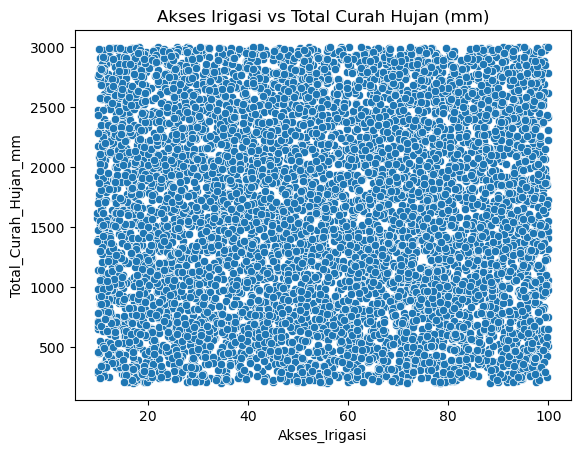

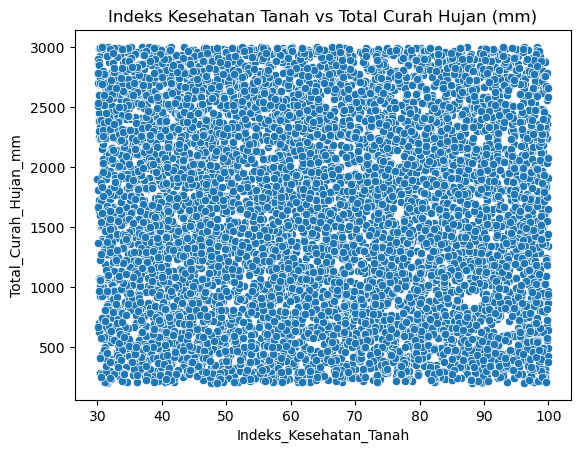

In [9]:
# pengecekan data-data tersebut melalui correlation
corr = df[['Total_Curah_Hujan_mm', 'Akses_Irigasi', 'Indeks_Kesehatan_Tanah']].corr()
display(corr)

sns.scatterplot(x='Akses_Irigasi', y='Total_Curah_Hujan_mm', data=df)
plt.title('Akses Irigasi vs Total Curah Hujan (mm)')
plt.show()

sns.scatterplot(x='Indeks_Kesehatan_Tanah', y='Total_Curah_Hujan_mm', data=df)
plt.title('Indeks Kesehatan Tanah vs Total Curah Hujan (mm)')
plt.show()

Berdasarkan pengamatan dari pendekatan korelasi linear, beberapa data tersebut tampak lemah karena antar data menunjukkan yang lebih mendekati dengan 0.

In [ ]:
grouped = df.groupby('Wilayah')[['Total_Curah_Hujan_mm', 'Akses_Irigasi', 'Indeks_Kesehatan_Tanah']]
corr = grouped.corr()
unstacked = corr.unstack()
result = unstacked.iloc[:, 1] # type: ignore
result

Wilayah
'British Columbia'             -0.064506
'Grand Est'                    -0.003511
'New South Wales'               0.034151
'North Central'                -0.002183
'North West'                   -0.048039
'Provence-Alpes-Cote d’Azur'   -0.035954
'South East'                   -0.094108
'South West'                   -0.165426
'Tamil Nadu'                    0.111740
'West Bengal'                  -0.038027
'Western Australia'            -0.037348
Central                        -0.052112
East                            0.090818
Ile-de-France                  -0.092099
Maharashtra                    -0.048775
Midwest                         0.007202
North                           0.058150
Northeast                      -0.026739
Northwest                       0.065510
Northwestern                   -0.035543
Nouvelle-Aquitaine              0.031082
Ontario                         0.109647
Pampas                          0.082747
Patagonia                      -0.058931
Prairies

In [11]:
features = ['Akses_Irigasi', 'Indeks_Kesehatan_Tanah', 'Hasil_Panen_Ton_per_HA', 'Penggunaan_Pupuk_KG_per_HA']
train_df = df[df['Total_Curah_Hujan_mm'].notnull()]
X = train_df[features]
y = train_df['Total_Curah_Hujan_mm']

rf = RandomForestRegressor(random_state=RANDOM_SEED)
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Mean R² score:", scores.mean())

Mean R² score: -0.06311072772969975


Karena hasil $R^2$ rendah yang menunjukkan bahwa antar data tersebut tidak menunjukkan korelasi yang signifikan. Untuk langkah selanjutnya maka bisa dilakukan proses data imputation sederhana melalui pengisian dengan metode **median**.

In [12]:
df['Total_Curah_Hujan_mm'] = df.groupby(['Wilayah', 'Tahun'])['Total_Curah_Hujan_mm'].transform(
    lambda x: x.fillna(x.median())
)

#### **Hasil_Panen_Ton_per_HA** Column

Diasumsikan bahwa kolom **Hasil_Panen_Ton_per_HA** berkolerasi dengan data kolom **Jenis_Tanaman**, **Kejadian_Cuaca_Ekstrim**, **Penggunaan_Pestisida_KG_per_HA**, **Penggunaan_Pupuk_KG_per_HA**, dan **Strategi_Adaptasi**.

In [13]:
features = ['Jenis_Tanaman', 'Kejadian_Cuaca_Ekstrim',
            'Penggunaan_Pestisida_KG_per_HA', 'Penggunaan_Pupuk_KG_per_HA',
            'Strategi_Adaptasi']

# Copy data
train_df = df[df['Hasil_Panen_Ton_per_HA'].notnull()].copy()
test_df = df[df['Hasil_Panen_Ton_per_HA'].isnull()].copy()

# Fill missing categorical values BEFORE encoding
train_df['Jenis_Tanaman'] = train_df['Jenis_Tanaman'].fillna(train_df['Jenis_Tanaman'].mode()[0])
train_df['Strategi_Adaptasi'] = train_df['Strategi_Adaptasi'].fillna(train_df['Strategi_Adaptasi'].mode()[0])

test_df['Jenis_Tanaman'] = test_df['Jenis_Tanaman'].fillna(train_df['Jenis_Tanaman'].mode()[0])
test_df['Strategi_Adaptasi'] = test_df['Strategi_Adaptasi'].fillna(train_df['Strategi_Adaptasi'].mode()[0])

# Encode categorical features AFTER filling missing values
le_jenis = LabelEncoder()
le_strategi = LabelEncoder()

train_df['Jenis_Tanaman'] = le_jenis.fit_transform(train_df['Jenis_Tanaman'].astype(str))
train_df['Strategi_Adaptasi'] = le_strategi.fit_transform(train_df['Strategi_Adaptasi'].astype(str))

test_df['Jenis_Tanaman'] = le_jenis.transform(test_df['Jenis_Tanaman'].astype(str))
test_df['Strategi_Adaptasi'] = le_strategi.transform(test_df['Strategi_Adaptasi'].astype(str))

# Prepare data
X_train = train_df[features]
y_train = train_df['Hasil_Panen_Ton_per_HA']
X_test = test_df[features]

# Handle missing NUMERIC values only (after encoding, all features are numeric)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Train model
rf = RandomForestRegressor(random_state=RANDOM_SEED)
rf.fit(X_train, y_train)

# Evaluate model performance
scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print("Mean R² score:", np.mean(scores))

Mean R² score: -0.078833803414697


Hasil $R^2$ tergolong rendah bahkan mencapai nilai di bawah 0. Ini menunjukkan bahwa antar data kurang berkolerasi satu sama lain. Maka dari itu, untuk langkah selanjutnya teknik yang digunakan adalah dengan menggunakan *median*.

In [14]:
df['Hasil_Panen_Ton_per_HA'] = (
    df.groupby(['Jenis_Tanaman', 'Wilayah', 'Tahun'])['Hasil_Panen_Ton_per_HA']
      .transform(lambda x: x.fillna(x.median()))
)

# from the above method, it still show missing values
# Fallback 1: Jenis_Tanaman + Wilayah
df['Hasil_Panen_Ton_per_HA'] = (
    df.groupby(['Jenis_Tanaman', 'Wilayah'])['Hasil_Panen_Ton_per_HA']
      .transform(lambda x: x.fillna(x.median()))
)

# Fallback 2: Jenis_Tanaman + Tahun
df['Hasil_Panen_Ton_per_HA'] = (
    df.groupby(['Jenis_Tanaman', 'Tahun'])['Hasil_Panen_Ton_per_HA']
      .transform(lambda x: x.fillna(x.median()))
)

# Fallback 3: Wilayah + Tahun
df['Hasil_Panen_Ton_per_HA'] = (
    df.groupby(['Wilayah', 'Tahun'])['Hasil_Panen_Ton_per_HA']
      .transform(lambda x: x.fillna(x.median()))
)

# Fallback 4: Jenis_Tanaman only
df['Hasil_Panen_Ton_per_HA'] = (
    df.groupby('Jenis_Tanaman')['Hasil_Panen_Ton_per_HA']
      .transform(lambda x: x.fillna(x.median()))
)

# Fallback 5: Wilayah only
df['Hasil_Panen_Ton_per_HA'] = (
    df.groupby('Wilayah')['Hasil_Panen_Ton_per_HA']
      .transform(lambda x: x.fillna(x.median()))
)

# Final fallback: global median (guaranteed to fill everything)
df['Hasil_Panen_Ton_per_HA'] = df['Hasil_Panen_Ton_per_HA'].fillna(df['Hasil_Panen_Ton_per_HA'].median())

#### **Akses_Irigasi** Column

Data **Akses_Irigasi** ini diasumsikan memiliki korelasi dengan beberapa kolom berikut: *Total_Curah_Hujan_mm*, *Kejadian_Cuaca_Ekstrim*, *Nama_Negara*, *Wilayah*, *Tahun*, dan *Jenis_Tanaman*.

In [15]:
features = ['Total_Curah_Hujan_mm', 'Kejadian_Cuaca_Ekstrim', 
            'Nama_Negara', 'Wilayah', 'Tahun', 'Jenis_Tanaman']

# Prepare data
train_df = df[df['Akses_Irigasi'].notnull()].copy()
test_df = df[df['Akses_Irigasi'].isnull()].copy()

# Encode categorical
le_country = LabelEncoder()
le_region = LabelEncoder()
le_crop = LabelEncoder()

train_df['Nama_Negara'] = le_country.fit_transform(train_df['Nama_Negara'])
train_df['Wilayah'] = le_region.fit_transform(train_df['Wilayah'])
train_df['Jenis_Tanaman'] = le_crop.fit_transform(train_df['Jenis_Tanaman'].astype(str))

test_df['Nama_Negara'] = le_country.transform(test_df['Nama_Negara'])
test_df['Wilayah'] = le_region.transform(test_df['Wilayah'])
test_df['Jenis_Tanaman'] = le_crop.transform(test_df['Jenis_Tanaman'].astype(str))

X_train = train_df[features]
y_train = train_df['Akses_Irigasi']
X_test = test_df[features]

# Handle missing numeric values
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Train model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Evaluate model
scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print("Mean R² score:", np.mean(scores))

Mean R² score: -0.0736050041516366


Hasil $R^2$ sangat rendah karena di bawah $0$. Maka dari itu data imputation bisa menggunakan *median*

In [16]:
df['Akses_Irigasi'] = (
    df.groupby(['Wilayah', 'Jenis_Tanaman'])['Akses_Irigasi']
      .transform(lambda x: x.fillna(x.median()))
)

### 2.4.2 Machine Learning Approach

#### **Jenis_Tanaman** Column

In [ ]:
# features = ['Hasil_Panen_Ton_per_HA', 'Penggunaan_Pestisida_KG_per_HA',
#             'Penggunaan_Pupuk_KG_per_HA', 'Indeks_Kesehatan_Tanah']

# # Separate data
# train_df = df[df['Jenis_Tanaman'].notnull()]
# test_df = df[df['Jenis_Tanaman'].isnull()]

# # Encode Jenis_Tanaman
# le = LabelEncoder()
# y = le.fit_transform(train_df['Jenis_Tanaman'])

# # Impute missing numeric features if any
# imputer = SimpleImputer(strategy='median')
# X_train = imputer.fit_transform(train_df[features])
# X_test = imputer.transform(test_df[features])

# # Train classifier
# clf = RandomForestClassifier(random_state=42)
# clf.fit(X_train, y)

# # Predict
# preds = clf.predict(X_test)
# df.loc[df['Jenis_Tanaman'].isnull(), 'Jenis_Tanaman'] = le.inverse_transform(preds)

## 2.5 Hasil Data Imputation

In [17]:
print(f'Total data kosong: {df.isnull().values.sum()}')
display(df.isnull().sum())

Total data kosong: 217


ID                                  0
Tahun                               0
Nama_Negara                         0
Wilayah                             0
Jenis_Tanaman                       8
Total_Curah_Hujan_mm                1
Emisi_CO2_JT_Ton                    0
Hasil_Panen_Ton_per_HA              0
Kejadian_Cuaca_Ekstrim              0
Akses_Irigasi                       8
Penggunaan_Pestisida_KG_per_HA      0
Penggunaan_Pupuk_KG_per_HA          0
Indeks_Kesehatan_Tanah              0
Strategi_Adaptasi                   0
Suhu_Rata_Rata_C                    0
Pupuk_bin                           0
Pestisida_bin                       0
Hasil_bin                         200
dtype: int64

---

# 3. Exploratory Data Analysis (EDA)

In [ ]:
sns.relplot(
    data=df, x="Tahun", y="Total_Curah_Hujan_mm",
    col="Nama_Negara", kind="line",
    col_wrap=4,
)

In [ ]:
sns.relplot(
    data=df, x="Tahun", y="Suhu_Rata_Rata_C",
    col="Nama_Negara", kind="line",
    col_wrap=4,
)

In [ ]:
sns.relplot(
    data=df, x="Tahun", y="Emisi_CO2_JT_Ton",
    col="Nama_Negara", kind="line",
    col_wrap=4,
)

In [ ]:
sns.lmplot(
    data=df,
    x='Total_Curah_Hujan_mm',
    y='Akses_Irigasi',
    hue='Wilayah',
    col='Wilayah',
    col_wrap=4,
    scatter_kws={'alpha':0.5, 's':15},
    line_kws={'color':'red'}
)
plt.subplots_adjust(top=0.9)
plt.suptitle('Linear Regression per Wilayah: Rainfall vs Irrigation')
plt.show()

---

## 3.1 Basic Data Statistics

In [ ]:
plt.plot([i for i in range(len(df['Suhu_Rata_Rata_C']))], df['Suhu_Rata_Rata_C'])

In [ ]:
# Set style for better visuals
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 12)

print("=" * 80)
print("📊 TIME SERIES DATA EXPLORATION")
print("=" * 80)

# Basic statistics
print(f"\n📈 Dataset Overview:")
print(f"   Total records: {len(df):,}")
print(f"   Year range: {df['Tahun'].min()} - {df['Tahun'].max()} ({df['Tahun'].nunique()} years)")
print(f"   Regions: {df['Wilayah'].nunique()}")
print(f"   Countries: {df['Nama_Negara'].nunique()}")
print(f"   Crop types: {df['Jenis_Tanaman'].nunique()}")

# Missing value overview
print(f"\n❓ Missing Values Overview:")
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
if len(missing_summary) > 0:
    for col, count in missing_summary.items():
        pct = (count / len(df)) * 100
        print(f"   {col}: {count} ({pct:.2f}%)")
else:
    print("   ✅ No missing values detected!")

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

# ==========================================
# 1. Temperature Over Time (Global Trend)
# ==========================================
ax1 = fig.add_subplot(gs[0, :])
yearly_stats = df.groupby('Tahun')['Suhu_Rata_Rata_C'].agg(['mean', 'std', 'min', 'max'])

# Plot mean with std bands
ax1.plot(yearly_stats.index, yearly_stats['mean'], 'o-', linewidth=2, 
         markersize=6, color='#d62728', label='Mean Temperature')
ax1.fill_between(yearly_stats.index, 
                  yearly_stats['mean'] - yearly_stats['std'],
                  yearly_stats['mean'] + yearly_stats['std'],
                  alpha=0.3, color='#d62728', label='±1 Std Dev')

# Add trend line
z = np.polyfit(yearly_stats.index, yearly_stats['mean'], 1)
p = np.poly1d(z)
ax1.plot(yearly_stats.index, p(yearly_stats.index), '--', 
         linewidth=2, color='black', alpha=0.7, 
         label=f'Trend (slope={z[0]:.4f}°C/year)')

ax1.set_title('🌡️ Global Temperature Trend Over Time', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Temperature (°C)', fontsize=11)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# ==========================================
# 2. Temperature Distribution by Year
# ==========================================
ax2 = fig.add_subplot(gs[1, 0])
years_sample = sorted(df['Tahun'].unique())[::max(1, len(df['Tahun'].unique())//10)]  # Sample every N years
df_sample = df[df['Tahun'].isin(years_sample)]
sns.violinplot(data=df_sample, x='Tahun', y='Suhu_Rata_Rata_C', ax=ax2, palette='coolwarm')
ax2.set_title('📊 Temperature Distribution by Year', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('Temperature (°C)', fontsize=10)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# ==========================================
# 3. Regional Temperature Patterns
# ==========================================
ax3 = fig.add_subplot(gs[1, 1])
top_regions = df.groupby('Wilayah')['Suhu_Rata_Rata_C'].count().nlargest(6).index
for region in top_regions:
    region_data = df[df['Wilayah'] == region].groupby('Tahun')['Suhu_Rata_Rata_C'].mean()
    ax3.plot(region_data.index, region_data.values, 'o-', 
             label=region[:20], alpha=0.7, markersize=3, linewidth=1.5)
ax3.set_title('🗺️ Top 6 Regions Temperature Trends', fontsize=12, fontweight='bold')
ax3.set_xlabel('Year', fontsize=10)
ax3.set_ylabel('Temperature (°C)', fontsize=10)
ax3.legend(loc='best', fontsize=8, ncol=2)
ax3.grid(True, alpha=0.3)

# ==========================================
# 4. Year-over-Year Change
# ==========================================
ax4 = fig.add_subplot(gs[1, 2])
yearly_mean = df.groupby('Tahun')['Suhu_Rata_Rata_C'].mean()
yoy_change = yearly_mean.diff()
colors = ['#d62728' if x < 0 else '#2ca02c' for x in yoy_change.values]
ax4.bar(yoy_change.index, yoy_change.values, color=colors, alpha=0.7, edgecolor='black')
ax4.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax4.set_title('📈 Year-over-Year Temperature Change', fontsize=12, fontweight='bold')
ax4.set_xlabel('Year', fontsize=10)
ax4.set_ylabel('Change (°C)', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# ==========================================
# 5. Seasonality/Periodicity Check (Autocorrelation)
# ==========================================
ax5 = fig.add_subplot(gs[2, 0])
yearly_values = yearly_mean.values
max_lag = min(20, len(yearly_values) - 1)
acf_values = [1.0]  # lag 0 is always 1
for lag in range(1, max_lag + 1):
    if lag < len(yearly_values):
        corr = np.corrcoef(yearly_values[:-lag], yearly_values[lag:])[0, 1]
        acf_values.append(corr)

ax5.stem(range(len(acf_values)), acf_values, basefmt=" ")
ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax5.axhline(y=1.96/np.sqrt(len(yearly_values)), color='red', linestyle='--', linewidth=1, label='95% CI')
ax5.axhline(y=-1.96/np.sqrt(len(yearly_values)), color='red', linestyle='--', linewidth=1)
ax5.set_title('🔄 Autocorrelation (ACF)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Lag', fontsize=10)
ax5.set_ylabel('Correlation', fontsize=10)
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# ==========================================
# 6. Data Completeness Heatmap
# ==========================================
ax6 = fig.add_subplot(gs[2, 1])
# Count records per year per region
pivot_counts = df.pivot_table(
    values='Suhu_Rata_Rata_C', 
    index='Wilayah', 
    columns='Tahun', 
    aggfunc='count'
)
# Sample top regions if too many
if len(pivot_counts) > 20:
    pivot_counts = pivot_counts.iloc[:20]

sns.heatmap(pivot_counts, cmap='YlGnBu', cbar_kws={'label': 'Record Count'}, 
            ax=ax6, linewidths=0.5, linecolor='white')
ax6.set_title('📅 Data Completeness (Year × Region)', fontsize=12, fontweight='bold')
ax6.set_xlabel('Year', fontsize=10)
ax6.set_ylabel('Region', fontsize=10)

# ==========================================
# 7. Missing Data Pattern
# ==========================================
ax7 = fig.add_subplot(gs[2, 2])
missing_by_year = df.groupby('Tahun').apply(lambda x: x.isnull().sum().sum())
ax7.bar(missing_by_year.index, missing_by_year.values, color='#ff7f0e', alpha=0.7, edgecolor='black')
ax7.set_title('❓ Missing Values Over Time', fontsize=12, fontweight='bold')
ax7.set_xlabel('Year', fontsize=10)
ax7.set_ylabel('Total Missing Values', fontsize=10)
ax7.grid(True, alpha=0.3, axis='y')

# ==========================================
# 8. Distribution of Key Features
# ==========================================
ax8 = fig.add_subplot(gs[3, 0])
key_features = ['Total_Curah_Hujan_mm', 'Emisi_CO2_JT_Ton', 'Hasil_Panen_Ton_per_HA']
df[key_features].hist(bins=30, ax=ax8, alpha=0.7, edgecolor='black')
ax8.set_title('📊 Key Features Distribution', fontsize=12, fontweight='bold')

# ==========================================
# 9. Correlation with Temperature
# ==========================================
ax9 = fig.add_subplot(gs[3, 1])
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['Suhu_Rata_Rata_C'].drop('Suhu_Rata_Rata_C').sort_values(ascending=False)
top_corr = correlations.head(10)
colors_corr = ['#2ca02c' if x > 0 else '#d62728' for x in top_corr.values]
ax9.barh(range(len(top_corr)), top_corr.values, color=colors_corr, alpha=0.7, edgecolor='black')
ax9.set_yticks(range(len(top_corr)))
ax9.set_yticklabels(top_corr.index, fontsize=9)
ax9.set_xlabel('Correlation with Temperature', fontsize=10)
ax9.set_title('🔗 Top Correlations with Temperature', fontsize=12, fontweight='bold')
ax9.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax9.grid(True, alpha=0.3, axis='x')

# ==========================================
# 10. Outlier Detection
# ==========================================
ax10 = fig.add_subplot(gs[3, 2])
# Z-score based outlier detection
z_scores = np.abs(stats.zscore(df['Suhu_Rata_Rata_C'].dropna()))
outliers = df['Suhu_Rata_Rata_C'][z_scores > 3]
ax10.scatter(df['Tahun'], df['Suhu_Rata_Rata_C'], alpha=0.3, s=10, label='Normal', color='blue')
if len(outliers) > 0:
    ax10.scatter(df.loc[outliers.index, 'Tahun'], outliers, 
                 color='red', s=50, marker='x', label=f'Outliers (n={len(outliers)})', zorder=5)
ax10.set_title('🎯 Outlier Detection (Z-score > 3)', fontsize=12, fontweight='bold')
ax10.set_xlabel('Year', fontsize=10)
ax10.set_ylabel('Temperature (°C)', fontsize=10)
ax10.legend(fontsize=9)
ax10.grid(True, alpha=0.3)

plt.suptitle('TIME SERIES DATA EXPLORATION DASHBOARD', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

# ==========================================
# Summary Statistics Table
# ==========================================
print("\n" + "=" * 80)
print("📋 SUMMARY STATISTICS")
print("=" * 80)

summary_stats = pd.DataFrame({
    'Mean': df.select_dtypes(include=[np.number]).mean(),
    'Std': df.select_dtypes(include=[np.number]).std(),
    'Min': df.select_dtypes(include=[np.number]).min(),
    'Max': df.select_dtypes(include=[np.number]).max(),
    'Missing': df.select_dtypes(include=[np.number]).isnull().sum(),
    'Missing %': (df.select_dtypes(include=[np.number]).isnull().sum() / len(df) * 100).round(2)
})

display(summary_stats)

# ==========================================
# Temporal Patterns Analysis
# ==========================================
print("\n" + "=" * 80)
print("🕒 TEMPORAL PATTERNS")
print("=" * 80)

print(f"\n✅ Trend Analysis:")
print(f"   Overall temperature change: {yearly_mean.iloc[-1] - yearly_mean.iloc[0]:.4f}°C")
print(f"   Average yearly change: {z[0]:.6f}°C/year")
print(f"   Total years: {df['Tahun'].nunique()}")

print(f"\n✅ Volatility:")
print(f"   Overall std: {df['Suhu_Rata_Rata_C'].std():.4f}°C")
print(f"   Mean YoY change: {yoy_change.mean():.4f}°C")
print(f"   Max YoY increase: {yoy_change.max():.4f}°C")
print(f"   Max YoY decrease: {yoy_change.min():.4f}°C")

print(f"\n✅ Seasonality/Periodicity:")
max_acf_lag = np.argmax(np.abs(acf_values[1:])) + 1 if len(acf_values) > 1 else None
if max_acf_lag:
    print(f"   Strongest autocorrelation at lag: {max_acf_lag} (corr={acf_values[max_acf_lag]:.3f})")
else:
    print(f"   No clear seasonal pattern detected")

print("\n" + "=" * 80)

In [ ]:
df['Tahun'].describe()

## 3.2 Visualisasi untuk ditambahkan pada makalah

In [ ]:
df['Suhu_Rata_Rata_C'].describe()

In [ ]:
stats = (
    df.groupby('Nama_Negara')['Suhu_Rata_Rata_C']
      .agg(['min', 'max', 'mean', 'std'])
      .reset_index()
)

# Rename columns for clarity
stats.columns = ['Negara', 'Minimum (°C)', 'Maksimum (°C)', 'Rata-rata (°C)', 'Standar Deviasi']

# Optional: Round to 2 decimal places for cleaner display
stats = stats.round(2)

display(stats)
# print(stats)

stats.to_csv('statistik_suhu_per_negara.csv', index=False)

## 3.3 Advance Visualization

In [ ]:
# Prepare data
yearly_stats = df.groupby('Tahun').agg({
    'Suhu_Rata_Rata_C': ['mean', 'min', 'max', 'std', 'count']
}).reset_index()
yearly_stats.columns = ['Year', 'Mean', 'Min', 'Max', 'Std', 'Count']

# Create interactive dashboard
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=(
        'Average Temperature with Range',
        'Data Point Count per Year',
        'Temperature Volatility (Std Dev)'
    ),
    vertical_spacing=0.12,
    row_heights=[0.5, 0.25, 0.25]
)

# Plot 1: Temperature with min-max range
fig.add_trace(
    go.Scatter(
        x=yearly_stats['Year'],
        y=yearly_stats['Mean'],
        mode='lines+markers',
        name='Mean Temperature',
        line=dict(color='red', width=3),
        marker=dict(size=8),
        hovertemplate='Year: %{x}<br>Mean: %{y:.2f}°C<extra></extra>'
    ),
    row=1, col=1
)

# Add range (min-max)
fig.add_trace(
    go.Scatter(
        x=yearly_stats['Year'],
        y=yearly_stats['Max'],
        mode='lines',
        line=dict(width=0),
        showlegend=False,
        hoverinfo='skip'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=yearly_stats['Year'],
        y=yearly_stats['Min'],
        mode='lines',
        line=dict(width=0),
        fillcolor='rgba(255, 0, 0, 0.2)',
        fill='tonexty',
        name='Min-Max Range',
        hovertemplate='Year: %{x}<br>Min: %{y:.2f}°C<extra></extra>'
    ),
    row=1, col=1
)

# Plot 2: Data count
fig.add_trace(
    go.Bar(
        x=yearly_stats['Year'],
        y=yearly_stats['Count'],
        name='Data Points',
        marker_color='lightblue',
        hovertemplate='Year: %{x}<br>Count: %{y}<extra></extra>'
    ),
    row=2, col=1
)

# Plot 3: Volatility
fig.add_trace(
    go.Scatter(
        x=yearly_stats['Year'],
        y=yearly_stats['Std'],
        mode='lines+markers',
        name='Std Deviation',
        line=dict(color='orange', width=2),
        marker=dict(size=6),
        hovertemplate='Year: %{x}<br>Std: %{y:.2f}°C<extra></extra>'
    ),
    row=3, col=1
)

# Update layout
fig.update_layout(
    height=900,
    title_text="📊 Interactive Time Series Dashboard",
    showlegend=True,
    hovermode='x unified'
)

fig.update_xaxes(title_text="Year", row=3, col=1)
fig.update_yaxes(title_text="Temperature (°C)", row=1, col=1)
fig.update_yaxes(title_text="Count", row=2, col=1)
fig.update_yaxes(title_text="Std Dev (°C)", row=3, col=1)

fig.show()

In [ ]:
# Check for issues
print("🔍 Data Diagnostics:")
print(f"Target range: {df['Suhu_Rata_Rata_C'].min():.2f} to {df['Suhu_Rata_Rata_C'].max():.2f}")
print(f"Target mean: {df['Suhu_Rata_Rata_C'].mean():.2f}")
print(f"Target std: {df['Suhu_Rata_Rata_C'].std():.2f}")
print(f"\nZero values in target: {(df['Suhu_Rata_Rata_C'] == 0).sum()}")
print(f"Negative values in target: {(df['Suhu_Rata_Rata_C'] < 0).sum()}")
print(f"Missing values in target: {df['Suhu_Rata_Rata_C'].isnull().sum()}")

# 4. Feature Engineering & Selection

Data-data yang mungkin menjadi data fitur:
- Total_Curah_Hujan_mm
- Emisi_CO2_JT_Ton

In [12]:
print(f'Nama-nama negara: {df['Nama_Negara'].unique()}')
print(f'Wilayah-wilayah unik: ({df['Wilayah'].nunique()}) {df['Wilayah'].unique()}')

print(f'\nRentetan tahun: {df['Tahun'].unique()}')
print(f'\nJenis-jenis tanaman: {df['Jenis_Tanaman'].unique()}')
print(f'Strategi-strategi adaptasi: {df['Strategi_Adaptasi'].unique()}')

Nama-nama negara: ['Argentina' 'Australia' 'Brazil' 'Canada' 'China' 'France' 'India'
 'Nigeria' 'Russia' 'USA']
Wilayah-wilayah unik: (34) ['Northeast' 'Northwest' 'Pampas' 'Patagonia' "'New South Wales'"
 "'Western Australia'" 'Queensland' 'Victoria' 'North' 'South' 'Southeast'
 "'British Columbia'" 'Ontario' 'Prairies' 'Quebec' 'Central' 'East'
 "'Grand Est'" "'Provence-Alpes-Cote d’Azur'" 'Ile-de-France'
 'Nouvelle-Aquitaine' "'Tamil Nadu'" "'West Bengal'" 'Maharashtra'
 'Punjab' "'North Central'" "'North West'" "'South East'" "'South West'"
 'Northwestern' 'Siberian' 'Volga' 'Midwest' 'West']

Rentetan tahun: [1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024]

Jenis-jenis tanaman: ['Coffee' 'Corn' 'Cotton' 'Fruits' 'Rice' 'Sugarcane' 'Vegetables' nan
 'Barley' 'Soybeans' 'Wheat']
Strategi-strategi adaptasi: ['Tanpa Adaptasi' 'Manajemen Air' 'Rotasi Tanama

---

In [ ]:
# Handle missing values
numeric_features = ['Total_Curah_Hujan_mm', 'Hasil_Panen_Ton_per_HA', 'Akses_Irigasi']
categorical_features = ['Jenis_Tanaman', 'Nama_Negara', 'Wilayah', 'Strategi_Adaptasi']

# Impute numeric features with median
numeric_imputer = SimpleImputer(strategy='median')
df[numeric_features] = numeric_imputer.fit_transform(df[numeric_features])

# Impute categorical with mode
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_features] = cat_imputer.fit_transform(df[categorical_features])

# Encode categorical variables
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le

# Feature engineering
df['CO2_per_Rainfall'] = df['Emisi_CO2_JT_Ton'] / (df['Total_Curah_Hujan_mm'] + 1)
df['Pesticide_per_Fertilizer'] = df['Penggunaan_Pestisida_KG_per_HA'] / (df['Penggunaan_Pupuk_KG_per_HA'] + 1)
df['Yield_Efficiency'] = df['Hasil_Panen_Ton_per_HA'] * df['Indeks_Kesehatan_Tanah'] / 100

# Prepare features and target
feature_cols = [col for col in df.columns if col not in ['Suhu_Rata_Rata_C', 'ID'] + categorical_features]
X = df[feature_cols]
y = df['Suhu_Rata_Rata_C']

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 5. Model Definition

In [ ]:
# Build Darts TimeSeries from the already preprocessed DataFrame
import os, sys
from pathlib import Path

# Ensure project root (containing the `darts/` package) is on Python path when running from the notebook folder
proj_root = Path.cwd().resolve().parent
if (proj_root / "darts" / "__init__.py").exists():
    sys.path.insert(0, str(proj_root))

from darts import TimeSeries
from darts.models import (
    LightGBMModel,
    XGBModel,
    RegressionEnsembleModel,
    LinearRegressionModel,
    NaiveDrift,
    NaiveSeasonal,
)
from darts.dataprocessing.transformers import Scaler
from sklearn.metrics import mean_absolute_percentage_error

# Prepare an explicit integer time axis for robustness
_df_ts = df.copy()
_df_ts["t"] = np.arange(len(_df_ts))

# Target series
series_target = TimeSeries.from_dataframe(
    _df_ts, time_col="t", value_cols=["Suhu_Rata_Rata_C"]
)

# Use engineered numeric columns as past covariates
# covar_cols = [c for c in feature_cols if c != "Suhu_Rata_Rata_C"]
covar_cols = list(feature_cols)
series_cov = TimeSeries.from_dataframe(
    _df_ts[["t"] + covar_cols], time_col="t", value_cols=covar_cols
)

# Scale target and covariates to stabilize training and avoid near-zero issues
scaler_y = Scaler()
scaler_x = Scaler()
series_target_s = scaler_y.fit_transform(series_target)
series_cov_s = scaler_x.fit_transform(series_cov)

# Temporal split that respects order
split_idx = int(len(_df_ts) * 0.8)
split_point = series_target_s.time_index[split_idx]
series_trg_train, series_trg_val = series_target_s.split_before(split_point)
series_cov_train, series_cov_val = series_cov_s.split_before(split_point)


# Simple heuristic to infer a reasonable seasonal period K for NaiveSeasonal using ACF
# Falls back to K=1 (last value) if no strong seasonal signal is detected
def infer_seasonal_period(values, max_k=24, min_k=2, threshold=0.3):
    x = np.asarray(values).reshape(-1)
    if len(x) < (min_k * 3):
        return 1, 0.0
    x = x - x.mean()
    best_k, best_corr = 1, 0.0
    # don't search beyond a third of the series length for stability
    upper = min(max_k, max(min_k, len(x) // 3))
    for k in range(min_k, upper + 1):
        # pearson correlation between series and lagged series
        try:
            corr = np.corrcoef(x[:-k], x[k:])[0, 1]
        except Exception:
            corr = 0.0
        if np.isfinite(corr) and corr > best_corr:
            best_corr = float(corr)
            best_k = int(k)
    if best_corr >= threshold:
        return best_k, best_corr
    return 1, best_corr


# Infer K on the original (unscaled) target to keep interpretability
K_guess, K_score = infer_seasonal_period(
    _df_ts["Suhu_Rata_Rata_C"].values,
    max_k=min(48, max(3, len(_df_ts) // 2)),
    min_k=2,
    threshold=0.3,
)
K_guess = 12
print(f"🔎 Inferred seasonal K = {K_guess} (ACF={K_score:.2f})")

# Define base forecasting models
# Use enough lags to cover at least one seasonal cycle if K_guess>1; cap to avoid overfitting on small data
lgbm_lags = max(12, int(K_guess))

chunk_length = 1

lgbm_base = LightGBMModel(
    lags=lgbm_lags * 2,
    lags_past_covariates=lgbm_lags,
    lags_future_covariates=None,
    output_chunk_length=chunk_length,
    random_state=42,
)

# XGBoost baseline with the same lag configuration as LightGBM
xgb_base = XGBModel(
    lags=lgbm_lags * 2,
    lags_past_covariates=lgbm_lags,
    lags_future_covariates=None,
    output_chunk_length=chunk_length,
    random_state=42,
)

# LinearRegression baseline over lagged target + past covariates
linreg_base = LinearRegressionModel(
    lags=lgbm_lags,
    lags_past_covariates=lgbm_lags*10,
    # output_chunk_length=12,
    # output_chunk_shift=12,
)

# Naive baselines
naive_drift = NaiveDrift()
naive_seasonal = NaiveSeasonal(K=max(2, int(K_guess)))

base_models = [
    lgbm_base,
    xgb_base,
    # linreg_base,
    naive_drift,
    naive_seasonal,
]

# Build RegressionEnsembleModel
# The meta-regressor will learn how to combine base models' predictions on the last n points of the training set.
model_ts = RegressionEnsembleModel(
    forecasting_models=base_models,
    regression_train_n_points=max(12, int(min(48, K_guess))),
)

# Fit on training slice (scaled)
model_ts.fit(
    series=series_trg_train,
    past_covariates=series_cov_train,
    verbose=False,
)

# Predict the length of the validation slice autoregressively (scaled)
pred_val_s = model_ts.predict(len(series_trg_val), past_covariates=series_cov_s)

# Inverse-transform predictions and validation for metric computation
pred_val = scaler_y.inverse_transform(pred_val_s)
series_trg_val_orig = scaler_y.inverse_transform(series_trg_val)

# Compute a robust MAPE on the validation horizon
mape_ts = float(
    np.mean(
        np.abs(
            (series_trg_val_orig.values() - pred_val.values())
            / np.maximum(np.abs(series_trg_val_orig.values()), 1e-6)
        )
    )
    * 100.0
)
print(f"📈 Darts RegressionEnsembleModel Validation MAPE: {mape_ts:.4f}%")

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

X = np.arange(10).reshape(-1, 1)
y = np.arange(10)

display(X)
display(y)

tscv = TimeSeriesSplit(n_splits=9)

for train_index, test_index in  tscv.split(X):
    print("TRAIN indices:", train_index, "TEST indices:", test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

display(tscv)

In [ ]:
# Check predictions distribution for either Darts (pred_val) or sklearn (y_pred_val)
print("\n📊 Validation Predictions:")

pred_arr = None
actual_arr = None

# Prefer Darts variables if present
if 'pred_val' in globals() or 'pred_val' in locals():
    try:
        pred_arr = np.asarray(pred_val.values()).reshape(-1)
        actual_arr = np.asarray(series_trg_val_orig.values()).reshape(-1)
    except Exception as e:
        print(f"⚠️ Unable to extract values from Darts TimeSeries: {e}")

# # Fallback to sklearn variables
# if pred_arr is None and (('y_pred_val' in globals()) or ('y_pred_val' in locals())):
#     pred_arr = np.asarray(y_pred_val).reshape(-1)
#     # ensure lengths match in case y_val is longer
#     if 'y_val' in globals() or 'y_val' in locals():
#         actual_arr = np.asarray(y_val.iloc[: len(pred_arr)].values).reshape(-1)

if pred_arr is None or actual_arr is None:
    print("❌ No predictions found. Run either the Darts RegressionEnsembleModel section (producing pred_val) or the sklearn section (producing y_pred_val) first.")
else:
    print(f"Pred range: {pred_arr.min():.2f} to {pred_arr.max():.2f}")
    print(f"Pred mean: {pred_arr.mean():.2f}")
    print(f"Actual range: {actual_arr.min():.2f} to {actual_arr.max():.2f}")
    print(f"Actual mean: {actual_arr.mean():.2f}")

    # Check for near-zero predictions (causes huge MAPE)
    near_zero_mask = np.abs(pred_arr) < 0.1
    print(f"\n⚠️ Predictions near zero: {near_zero_mask.sum()} / {len(pred_arr)}")
    if near_zero_mask.sum() > 0:
        print(f"Actual values for near-zero predictions: {actual_arr[near_zero_mask]}")

In [ ]:
# Plot Actual vs Predicted (validation) using Darts plotting utilities
import numpy as np
import matplotlib.pyplot as plt
from darts.utils.statistics import plot_residuals_analysis

# Ensure we have TimeSeries predictions and actuals
try:
    series_trg_val_orig  # type: ignore[name-defined]
    pred_val  # type: ignore[name-defined]
except NameError:
    print("❌ No predictions to plot. Run the validation prediction cell first.")
    raise

# Robust MAPE computed from TimeSeries (handles zeros via epsilon clamp)
def _safe_mape_ts(actual_ts, pred_ts):
    try:
        # Align on intersection in time to avoid mismatched indices
        a = actual_ts.slice_intersect(pred_ts)
        p = pred_ts.slice_intersect(actual_ts)
        y_true = a.values().reshape(-1)
        y_pred = p.values().reshape(-1)
    except Exception:
        # Fallback: directly use provided series values
        y_true = np.asarray(series_trg_val_orig.values()).reshape(-1)
        y_pred = np.asarray(pred_val.values()).reshape(-1)
    eps = 1e-6
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100.0)

mape_plot = _safe_mape_ts(series_trg_val_orig, pred_val)

# Overlay plot using Darts' TimeSeries.plot
ax = series_trg_val_orig.plot(label="Actual")
pred_val.plot(ax=ax, label="Predicted")
ax.set_title(f"Validation: Actual vs Predicted (MAPE={mape_plot:.2f}%)")
ax.set_xlabel("Time")
ax.set_ylabel("Suhu_Rata_Rata_C")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Optional: Residuals analysis using Darts utility (values, histogram, ACF)
try:
    residuals = series_trg_val_orig - pred_val
    plot_residuals_analysis(residuals)
except Exception as e:
    print(f"ℹ️ Residual analysis skipped: {e}")

# 6. Model Training

# 7. Model Evaluation

# 8. Generate Predictions

In [ ]:
# Load test data
df_test = pd.read_csv(paths['test_csv'])

# Apply same preprocessing
df_test[numeric_features] = numeric_imputer.transform(df_test[numeric_features])
df_test[categorical_features] = cat_imputer.transform(df_test[categorical_features])

for col in categorical_features:
    df_test[f'{col}_encoded'] = label_encoders[col].transform(df_test[col])

# Feature engineering on test
df_test['CO2_per_Rainfall'] = df_test['Emisi_CO2_JT_Ton'] / (df_test['Total_Curah_Hujan_mm'] + 1)
df_test['Pesticide_per_Fertilizer'] = df_test['Penggunaan_Pestisida_KG_per_HA'] / (df_test['Penggunaan_Pupuk_KG_per_HA'] + 1)
df_test['Yield_Efficiency'] = df_test['Hasil_Panen_Ton_per_HA'] * df_test['Indeks_Kesehatan_Tanah'] / 100

X_test = df_test[feature_cols]
X_test_scaled = scaler.transform(X_test)  # kept in case you also run the sklearn path

# --- Darts prediction path ---
# Build a future time index for test and extend covariates into the future so models with lags_past_covariates can predict autoregressively
try:
    # Ensure we have the training _df_ts and covariate/Scaler objects from the Darts section
    if '_df_ts' not in globals() and '_df_ts' not in locals():
        raise RuntimeError("Darts training variables not found. Run the Darts training cell first.")
    if 'scaler_x' not in globals() and 'scaler_x' not in locals():
        raise RuntimeError("Darts scalers not found. Run the Darts training cell first.")

    # Create future time index continuing after the last training step
    df_test_ts = df_test.copy()
    start_t = int(_df_ts['t'].iloc[-1]) + 1 if 't' in _df_ts.columns else len(_df_ts)
    df_test_ts['t'] = np.arange(start_t, start_t + len(df_test))

    # Build future covariates TimeSeries and append to training covariates, then scale consistently
    covar_cols = [c for c in feature_cols if c != 'Suhu_Rata_Rata_C']
    series_cov_future = TimeSeries.from_dataframe(df_test_ts[['t'] + covar_cols], time_col='t', value_cols=covar_cols)
    series_cov_full = series_cov.append(series_cov_future)
    series_cov_full_s = scaler_x.transform(series_cov_full)

    # Predict n steps equal to test length using the SAME training target series used at fit to ensure aligned time axis
    n_test = len(df_test)
    pred_test_s = model_ts.predict(n_test, series=series_trg_train, past_covariates=series_cov_full_s)
    pred_test = scaler_y.inverse_transform(pred_test_s)
    predictions = pred_test.values().reshape(-1)

    # Optional sanity clamp to plausible physical range based on train stats
    y_min, y_max = df['Suhu_Rata_Rata_C'].quantile(0.01), df['Suhu_Rata_Rata_C'].quantile(0.99)
    predictions = np.clip(predictions, y_min - 1.0, y_max + 1.0)
except Exception as e:
    # Fallback or explicit error to guide the user
    raise RuntimeError(f"Failed to generate Darts predictions. Ensure the Darts training cell ran successfully. Details: {e}")

# Save submission
submission = pd.DataFrame({
    'ID': df_test['ID'],
    'Suhu_Rata_Rata_C': predictions
})
submission_path = f"{paths['save_dir']}/submission_xgb.csv"
submission.to_csv(submission_path, index=False)
print(f"✅ Submission saved to {submission_path}")